# Single Company Model Training


## GRU training

Saving INFY.csv to INFY.csv
Data sample:
                       date     open     high      low    close   volume  \
0  2023-01-02T00:00:00+0530  1514.00  1526.50  1504.05  1524.00  3801140   
1  2023-01-03T00:00:00+0530  1519.85  1532.65  1515.10  1522.55  4551130   
2  2023-01-04T00:00:00+0530  1521.00  1521.00  1491.10  1494.80  7059590   
3  2023-01-05T00:00:00+0530  1505.90  1505.90  1469.25  1475.20  9868404   
4  2023-01-06T00:00:00+0530  1470.00  1475.00  1446.50  1448.50  6443714   

   empty  
0      0  
1      0  
2      0  
3      0  
4      0  
Train samples: 539, Validation samples: 135


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 64)             │        13,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,745 (61.50 KB)

 Trainable params: 15,745 (61.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 0.1531 - val_loss: 0.0014
Epoch 2/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0098 - val_loss: 0.0016
Epoch 3/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0066 - val_loss: 0.0019
Epoch 4/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0050 - val_loss: 0.0013
Epoch 5/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0044 - val_loss: 0.0016
Epoch 6/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0040 - val_loss: 0.0013
Epoch 7/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0040 - val_loss: 0.0014
Epoch 8/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0044 - val_loss: 0.0015
Epoch 9/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0035 - val_loss: 0.0012
Epoch 10/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0032 - val_loss: 0.0013
Epoch 11/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0028 - val_loss: 0.0015
Epoch 12/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0034 - val

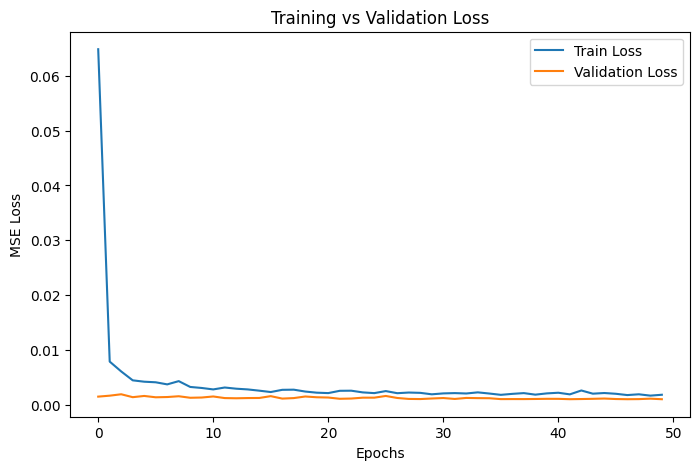

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


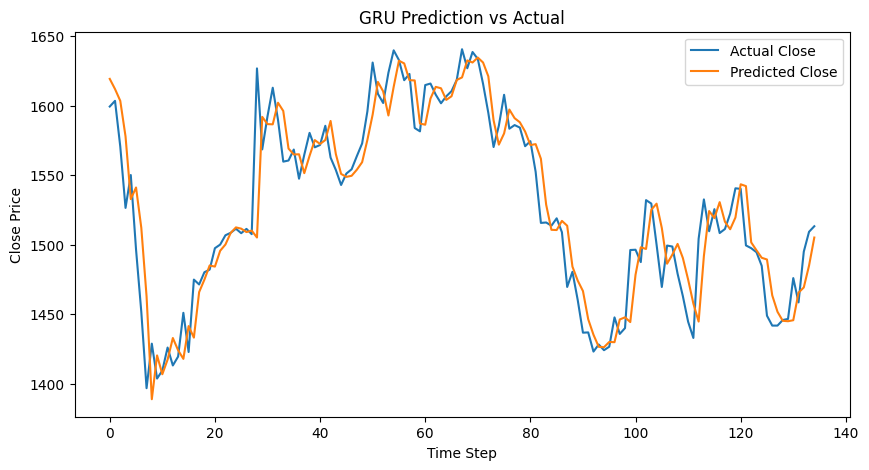

✅ Model saved as gru_stock_model.h5


In [ ]:
# ===============================
# 📘 GRU Stock Prediction Example
# ===============================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout
from sklearn.preprocessing import MinMaxScaler

# -------------------------------
# 1️⃣ Load Data
# -------------------------------
# Upload your CSV file
from google.colab import files
uploaded = files.upload()

# Assuming file name is something like data.csv
file_name = list(uploaded.keys())[0]
df = pd.read_csv(file_name)

print("Data sample:")
print(df.head())

# -------------------------------
# 2️⃣ Preprocess Data
# -------------------------------
# Drop empty or unused columns
df = df.drop(columns=['empty'], errors='ignore')

# Convert date to datetime (optional)
df['date'] = pd.to_datetime(df['date'])

# Sort by date (important if not sorted)
df = df.sort_values('date')

# We’ll use all numeric columns as features, but predict next 'close'
feature_cols = ['open', 'high', 'low', 'close', 'volume']
data = df[feature_cols].values

# Normalize
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data)

# -------------------------------
# 3️⃣ Create sequences for GRU
# -------------------------------
def create_sequences(dataset, seq_length=15):
    X, y = [], []
    for i in range(len(dataset) - seq_length):
        X.append(dataset[i:i+seq_length])
        y.append(dataset[i+seq_length, 3])  # column index 3 = 'close'
    return np.array(X), np.array(y)

SEQ_LEN = 15  # days of history
X, y = create_sequences(data_scaled, SEQ_LEN)

# Split into training and validation (80/20)
split = int(0.8 * len(X))
X_train, y_train = X[:split], y[:split]
X_val, y_val = X[split:], y[split:]

print(f"Train samples: {len(X_train)}, Validation samples: {len(X_val)}")

# -------------------------------
# 4️⃣ Build GRU Model
# -------------------------------
model = Sequential([
    GRU(64, return_sequences=False, input_shape=(SEQ_LEN, X.shape[2])),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')
model.summary()

# -------------------------------
# 5️⃣ Train
# -------------------------------
EPOCHS = 50
BATCH_SIZE = 16

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1
)

# -------------------------------
# 6️⃣ Plot Training Loss
# -------------------------------
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Training vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("MSE Loss")
plt.legend()
plt.show()

# -------------------------------
# 7️⃣ Make Predictions
# -------------------------------
y_pred = model.predict(X_val)

# Inverse scale predictions for real values
dummy = np.zeros((len(y_pred), data.shape[1]))
dummy[:,3] = y_pred[:,0]
predicted_close = scaler.inverse_transform(dummy)[:,3]

dummy2 = np.zeros((len(y_val), data.shape[1]))
dummy2[:,3] = y_val
actual_close = scaler.inverse_transform(dummy2)[:,3]

plt.figure(figsize=(10,5))
plt.plot(actual_close, label="Actual Close")
plt.plot(predicted_close, label="Predicted Close")
plt.title("GRU Prediction vs Actual")
plt.xlabel("Time Step")
plt.ylabel("Close Price")
plt.legend()
plt.show()

# -------------------------------
# 8️⃣ Save Model (optional)
# -------------------------------
model.save("gru_stock_model.h5")
print("✅ Model saved as gru_stock_model.h5")


## With Indicators

| Type             | Indicators       | Description                 |
| ---------------- | ---------------- | --------------------------- |
| **Trend**        | **EMA (12, 26)** | Exponential moving averages |
| **Momentum**     | **RSI (14)**     | Relative Strength Index     |
| **Volatility**   | **ATR (14)**     | Average True Range          |
| **Volume-based** | **OBV**          | On-Balance Volume           |


Saving INFY.csv to INFY (1).csv
Original Data Sample:
                       date     open     high      low    close   volume  \
0  2023-01-02T00:00:00+0530  1514.00  1526.50  1504.05  1524.00  3801140   
1  2023-01-03T00:00:00+0530  1519.85  1532.65  1515.10  1522.55  4551130   
2  2023-01-04T00:00:00+0530  1521.00  1521.00  1491.10  1494.80  7059590   
3  2023-01-05T00:00:00+0530  1505.90  1505.90  1469.25  1475.20  9868404   
4  2023-01-06T00:00:00+0530  1470.00  1475.00  1446.50  1448.50  6443714   

   empty  
0      0  
1      0  
2      0  
3      0  
4      0  

Data with Indicators:
                       date    open     high      low    close   volume  \
0 2023-01-19 00:00:00+05:30  1539.9  1549.55  1526.15  1538.90  6165284   
1 2023-01-20 00:00:00+05:30  1538.0  1545.00  1524.00  1525.55  6496429   
2 2023-01-23 00:00:00+05:30  1535.0  1553.30  1528.10  1548.00  4855020   
3 2023-01-24 00:00:00+05:30  1560.0  1568.80  1549.75  1551.90  5200802   
4 2023-01-25 00:00:00+05:

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_1 (GRU)                     │ (None, 20, 128)        │        53,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 20, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_2 (GRU)                     │ (None, 64)             │        37,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93,121 (363.75 KB)

 Trainable params: 93,121 (363.75 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/60
33/33 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - loss: 0.0419 - val_loss: 0.0020
Epoch 2/60
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0077 - val_loss: 0.0029
Epoch 3/60
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0074 - val_loss: 0.0039
Epoch 4/60
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0064 - val_loss: 0.0035
Epoch 5/60
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0050 - val_loss: 0.0027
Epoch 6/60
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0046 - val_loss: 0.0048
Epoch 7/60
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 0.0057 - val_loss: 0.0019
Epoch 8/60
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0040 - val_loss: 0.0017
Epoch 9/60
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0043 - val_loss: 0.0018
Epoch 10/60
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0043 - val_loss: 0.0016
Epoch 11/60
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0038 - val_loss: 0.0023
Epoch 12/60
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0

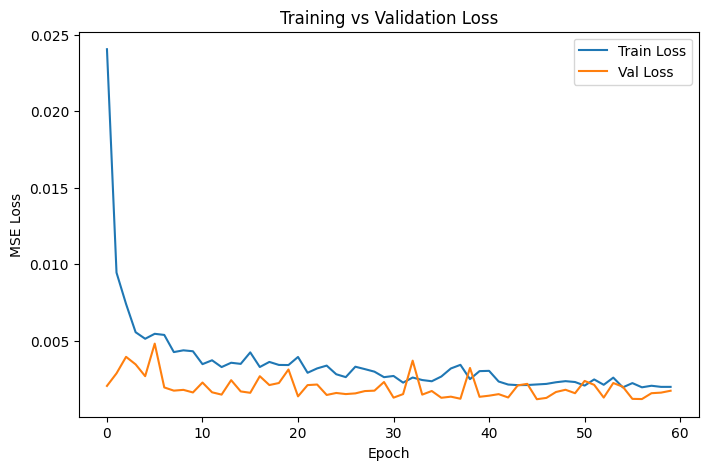

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 65ms/step


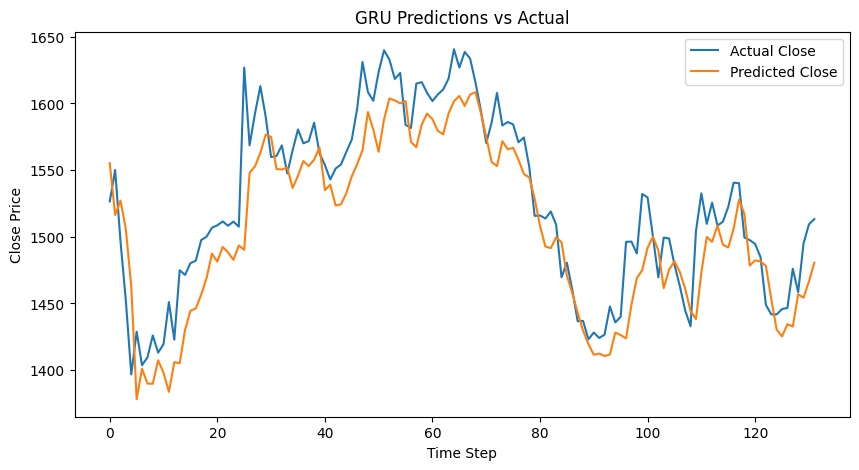

✅ Model saved as gru_with_indicators.h5


In [ ]:
# ===============================
# 📘 GRU Stock Prediction with Indicators
# ===============================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout
from sklearn.preprocessing import MinMaxScaler

# -------------------------------
# 1️⃣ Load Data
# -------------------------------
from google.colab import files
uploaded = files.upload()

file_name = list(uploaded.keys())[0]
df = pd.read_csv(file_name)

print("Original Data Sample:")
print(df.head())

# Drop 'empty' if present
df = df.drop(columns=['empty'], errors='ignore')

# Convert date
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date')

# -------------------------------
# 2️⃣ Add Technical Indicators
# -------------------------------

# Exponential Moving Averages
df['EMA12'] = df['close'].ewm(span=12, adjust=False).mean()
df['EMA26'] = df['close'].ewm(span=26, adjust=False).mean()

# RSI (Relative Strength Index)
def compute_RSI(series, period=14):
    delta = series.diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=period).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=period).mean()
    RS = gain / (loss + 1e-9)
    return 100 - (100 / (1 + RS))

df['RSI'] = compute_RSI(df['close'])

# ATR (Average True Range)
high_low = df['high'] - df['low']
high_close = np.abs(df['high'] - df['close'].shift())
low_close = np.abs(df['low'] - df['close'].shift())
TR = pd.concat([high_low, high_close, low_close], axis=1).max(axis=1)
df['ATR'] = TR.rolling(window=14).mean()

# OBV (On-Balance Volume)
df['OBV'] = (np.sign(df['close'].diff()) * df['volume']).fillna(0).cumsum()

# Drop NaN created by rolling windows
df = df.dropna().reset_index(drop=True)

print("\nData with Indicators:")
print(df.head())

# -------------------------------
# 3️⃣ Feature Preparation
# -------------------------------
feature_cols = [
    'open', 'high', 'low', 'close', 'volume',
    'EMA12', 'EMA26', 'RSI', 'ATR', 'OBV'
]
data = df[feature_cols].values

# Normalize
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data)

# -------------------------------
# 4️⃣ Create Sequences for GRU
# -------------------------------
def create_sequences(dataset, seq_length=20):
    X, y = [], []
    for i in range(len(dataset) - seq_length):
        X.append(dataset[i:i+seq_length])
        y.append(dataset[i+seq_length, 3])  # 3 = 'close'
    return np.array(X), np.array(y)

SEQ_LEN = 20
X, y = create_sequences(data_scaled, SEQ_LEN)

# Train/Val split
split = int(0.8 * len(X))
X_train, y_train = X[:split], y[:split]
X_val, y_val = X[split:], y[split:]

print(f"\nTrain: {X_train.shape}, Validation: {X_val.shape}")

# -------------------------------
# 5️⃣ GRU Model
# -------------------------------
model = Sequential([
    GRU(128, return_sequences=True, input_shape=(SEQ_LEN, X.shape[2])),
    Dropout(0.3),
    GRU(64, return_sequences=False),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')
model.summary()

# -------------------------------
# 6️⃣ Train Model
# -------------------------------
EPOCHS = 60
BATCH_SIZE = 16

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1
)

# -------------------------------
# 7️⃣ Plot Loss
# -------------------------------
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.show()

# -------------------------------
# 8️⃣ Predictions
# -------------------------------
y_pred = model.predict(X_val)

# Inverse scaling
dummy = np.zeros((len(y_pred), data.shape[1]))
dummy[:,3] = y_pred[:,0]
predicted_close = scaler.inverse_transform(dummy)[:,3]

dummy2 = np.zeros((len(y_val), data.shape[1]))
dummy2[:,3] = y_val
actual_close = scaler.inverse_transform(dummy2)[:,3]

plt.figure(figsize=(10,5))
plt.plot(actual_close, label='Actual Close')
plt.plot(predicted_close, label='Predicted Close')
plt.title("GRU Predictions vs Actual")
plt.xlabel("Time Step")
plt.ylabel("Close Price")
plt.legend()
plt.show()

# -------------------------------
# 9️⃣ Save Model
# -------------------------------
model.save("gru_with_indicators.h5")
print("✅ Model saved as gru_with_indicators.h5")


## LSTM without Indicators

Please upload your stock data CSV file.


Saving INFY.csv to INFY.csv
Original Data Sample:
                        date     open     high      low    close    volume  oi
0  2023-11-28 00:00:00+05:30  1444.00  1445.00  1427.05  1442.70   3755373   0
1  2023-11-29 00:00:00+05:30  1451.10  1460.70  1449.80  1459.60   3875778   0
2  2023-11-30 00:00:00+05:30  1453.25  1460.65  1449.55  1455.15  10120867   0
3  2023-12-01 00:00:00+05:30  1459.90  1459.90  1446.15  1452.30   3489187   0
4  2023-12-04 00:00:00+05:30  1460.45  1471.90  1449.30  1464.35   5511948   0

Data with ONLY Base Features (OHLCV):
                       date     open     high      low    close    volume
0 2023-11-28 00:00:00+05:30  1444.00  1445.00  1427.05  1442.70   3755373
1 2023-11-29 00:00:00+05:30  1451.10  1460.70  1449.80  1459.60   3875778
2 2023-11-30 00:00:00+05:30  1453.25  1460.65  1449.55  1455.15  10120867
3 2023-12-01 00:00:00+05:30  1459.90  1459.90  1446.15  1452.30   3489187
4 2023-12-04 00:00:00+05:30  1460.45  1471.90  1449.30  1464.35   5

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 20, 128)        │        68,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 20, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 120,129 (469.25 KB)

 Trainable params: 120,129 (469.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/60
24/24 ━━━━━━━━━━━━━━━━━━━━ 4s 46ms/step - loss: 0.0753 - val_loss: 0.0042
Epoch 2/60
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0139 - val_loss: 0.0045
Epoch 3/60
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0103 - val_loss: 0.0058
Epoch 4/60
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0096 - val_loss: 0.0041
Epoch 5/60
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0088 - val_loss: 0.0035
Epoch 6/60
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0082 - val_loss: 0.0040
Epoch 7/60
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0079 - val_loss: 0.0038
Epoch 8/60
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0102 - val_loss: 0.0056
Epoch 9/60
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 0.0084 - val_loss: 0.0040
Epoch 10/60
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 0.0079 - val_loss: 0.0029
Epoch 11/60
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0066 - val_loss: 0.0034
Epoch 12/60
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0

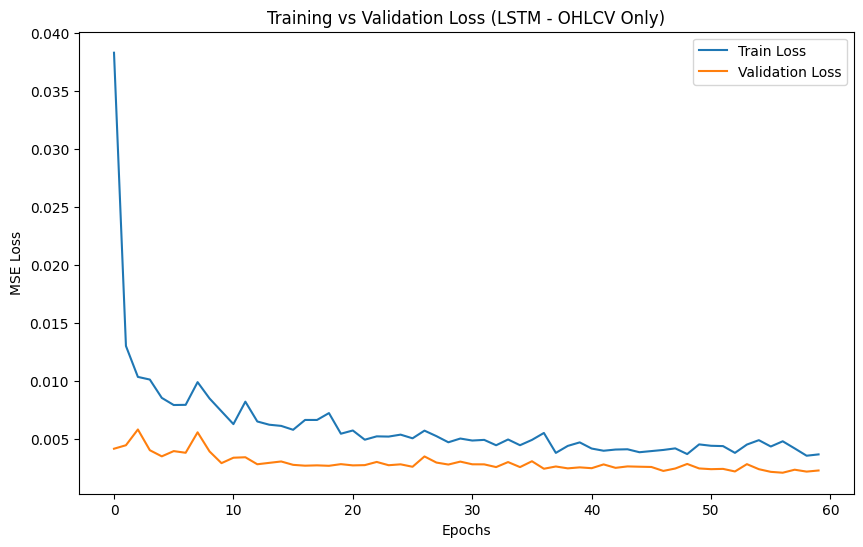

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step


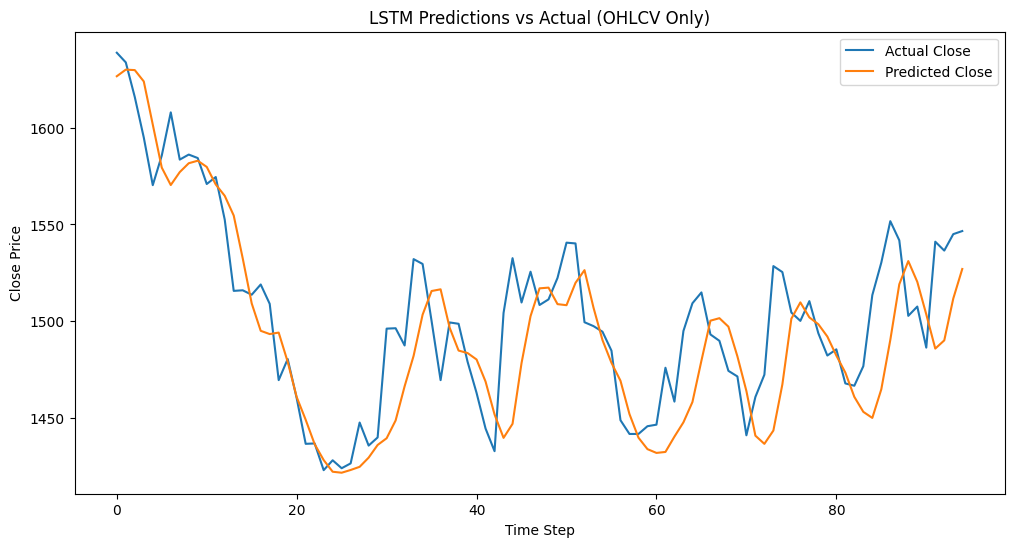

✅ Model saved as lstm_ohlcv_only.h5


In [1]:
# ============================================
# 📘 LSTM Stock Prediction with Base OHLCV
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.preprocessing import MinMaxScaler
from google.colab import files

# -------------------------------
# 1️⃣ Load Data
# -------------------------------
print("Please upload your stock data CSV file.")
try:
    uploaded = files.upload()
    file_name = list(uploaded.keys())[0]
    df = pd.read_csv(file_name)
except Exception as e:
    print(f"Error loading file: {e}. Please ensure you uploaded a file.")
    # Exit if file upload fails
    raise

print("Original Data Sample:")
print(df.head())

# Drop empty if exists
df = df.drop(columns=['empty'], errors='ignore')

# Convert and sort by date
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

# -------------------------------
# 2️⃣ Indicator Removal and Data Filtering
# -------------------------------

# --- MODIFICATION: ONLY BASE OHLCV USED ---
# Ensure only the base features are kept. No technical indicators are calculated.
# We also drop any rows that might have NaN values (though less likely here).
df = df[['date', 'open', 'high', 'low', 'close', 'volume']].dropna().reset_index(drop=True)

print("\nData with ONLY Base Features (OHLCV):")
print(df.head())

# -------------------------------
# 3️⃣ Feature Preparation
# -------------------------------
# --- MODIFICATION: ONLY BASE OHLCV USED ---
# The feature list is reduced to only the five base columns.
feature_cols = ['open', 'high', 'low', 'close', 'volume']
data = df[feature_cols].values

# Normalize
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data)

# -------------------------------
# 4️⃣ Create Sequences
# -------------------------------
def create_sequences(dataset, seq_length=20):
    X, y = [], []
    # Note: 'close' is at index 3 in the new feature_cols list
    CLOSE_INDEX = feature_cols.index('close')
    for i in range(len(dataset) - seq_length):
        X.append(dataset[i:i+seq_length])
        y.append(dataset[i+seq_length, CLOSE_INDEX])  # Predict the 'close' price
    return np.array(X), np.array(y)

SEQ_LEN = 20
X, y = create_sequences(data_scaled, SEQ_LEN)

# Train-validation split
split = int(0.8 * len(X))
X_train, y_train = X[:split], y[:split]
X_val, y_val = X[split:], y[split:]

print(f"\nTrain: {X_train.shape}, Validation: {X_val.shape}")

# -------------------------------
# 5️⃣ LSTM Model
# -------------------------------
# Input shape now reflects the reduced number of features (5 instead of 10)
model = Sequential([
    LSTM(128, return_sequences=True, input_shape=(SEQ_LEN, X.shape[2])),
    Dropout(0.3),
    LSTM(64, return_sequences=False),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')
model.summary()

# -------------------------------
# 6️⃣ Train Model
# -------------------------------
EPOCHS = 60
BATCH_SIZE = 16

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1
)

# -------------------------------
# 7️⃣ Plot Training Loss 📉
# -------------------------------
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Training vs Validation Loss (LSTM - OHLCV Only)")
plt.xlabel("Epochs")
plt.ylabel("MSE Loss")
plt.legend()
plt.show()

# -------------------------------
# 8️⃣ Make Predictions and Plot Results 📊
# -------------------------------
y_pred = model.predict(X_val)

# Inverse scaling for predictions
# --- MODIFICATION: DUMMY ARRAY SIZE ---
# The dummy array must match the number of original features (5)
dummy = np.zeros((len(y_pred), data.shape[1]))
dummy[:, feature_cols.index('close')] = y_pred[:, 0]
predicted_close = scaler.inverse_transform(dummy)[:, feature_cols.index('close')]

# Inverse scaling for actual values
dummy2 = np.zeros((len(y_val), data.shape[1]))
dummy2[:, feature_cols.index('close')] = y_val
actual_close = scaler.inverse_transform(dummy2)[:, feature_cols.index('close')]

plt.figure(figsize=(12, 6))
plt.plot(actual_close, label='Actual Close')
plt.plot(predicted_close, label='Predicted Close')
plt.title("LSTM Predictions vs Actual (OHLCV Only)")
plt.xlabel("Time Step")
plt.ylabel("Close Price")
plt.legend()
plt.show()

# -------------------------------
# 9️⃣ Save Model
# -------------------------------
model.save("lstm_ohlcv_only.h5")
print("✅ Model saved as lstm_ohlcv_only.h5")

## With Indicators with LSTM

| Feature          | GRU Model             | LSTM Model                 |
| ---------------- | --------------------- | -------------------------- |
| Architecture     | 128→64 GRU            | 128→64 LSTM                |
| Parameters       | Fewer                 | Slightly more              |
| Long-term memory | Moderate              | Stronger                   |
| Training speed   | Faster                | Slower                     |
| Use case         | Noisy short-term data | Trendy long-term sequences |


Saving INFY.csv to INFY (2).csv
Original Data Sample:
                       date     open     high      low    close   volume  \
0  2023-01-02T00:00:00+0530  1514.00  1526.50  1504.05  1524.00  3801140   
1  2023-01-03T00:00:00+0530  1519.85  1532.65  1515.10  1522.55  4551130   
2  2023-01-04T00:00:00+0530  1521.00  1521.00  1491.10  1494.80  7059590   
3  2023-01-05T00:00:00+0530  1505.90  1505.90  1469.25  1475.20  9868404   
4  2023-01-06T00:00:00+0530  1470.00  1475.00  1446.50  1448.50  6443714   

   empty  
0      0  
1      0  
2      0  
3      0  
4      0  

Data with Indicators:
                       date    open     high      low    close   volume  \
0 2023-01-19 00:00:00+05:30  1539.9  1549.55  1526.15  1538.90  6165284   
1 2023-01-20 00:00:00+05:30  1538.0  1545.00  1524.00  1525.55  6496429   
2 2023-01-23 00:00:00+05:30  1535.0  1553.30  1528.10  1548.00  4855020   
3 2023-01-24 00:00:00+05:30  1560.0  1568.80  1549.75  1551.90  5200802   
4 2023-01-25 00:00:00+05:

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 20, 128)        │        71,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 20, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,689 (479.25 KB)

 Trainable params: 122,689 (479.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/60
33/33 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - loss: 0.0757 - val_loss: 0.0073
Epoch 2/60
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0099 - val_loss: 0.0066
Epoch 3/60
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0080 - val_loss: 0.0045
Epoch 4/60
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0068 - val_loss: 0.0044
Epoch 5/60
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0055 - val_loss: 0.0040
Epoch 6/60
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0057 - val_loss: 0.0055
Epoch 7/60
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0060 - val_loss: 0.0047
Epoch 8/60
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0052 - val_loss: 0.0036
Epoch 9/60
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0054 - val_loss: 0.0060
Epoch 10/60
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0070 - val_loss: 0.0047
Epoch 11/60
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0053 - val_loss: 0.0048
Epoch 12/60
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0

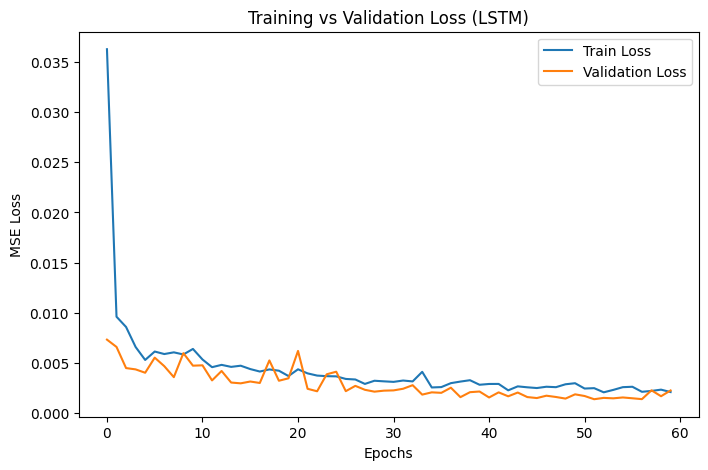

1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 193ms/step

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step


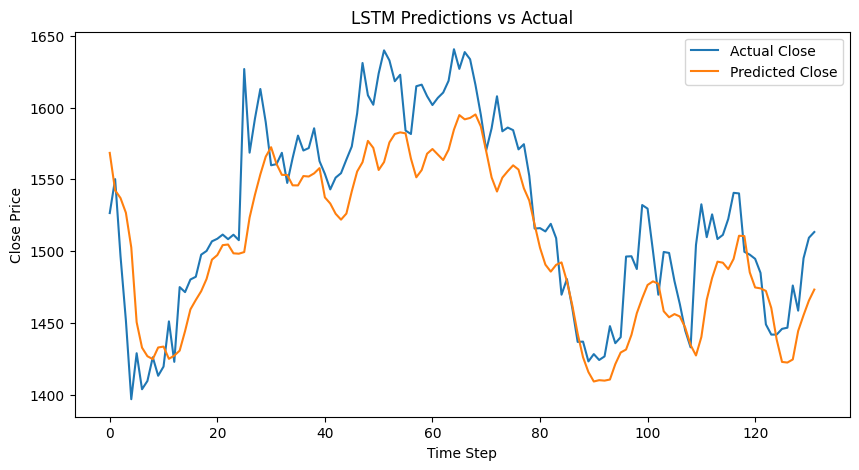

✅ Model saved as lstm_with_indicators.h5


In [ ]:
# ============================================
# 📘 LSTM Stock Prediction with Indicators
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.preprocessing import MinMaxScaler

# -------------------------------
# 1️⃣ Load Data
# -------------------------------
from google.colab import files
uploaded = files.upload()

file_name = list(uploaded.keys())[0]
df = pd.read_csv(file_name)

print("Original Data Sample:")
print(df.head())

# Drop empty if exists
df = df.drop(columns=['empty'], errors='ignore')

# Convert and sort by date
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date')

# -------------------------------
# 2️⃣ Add Technical Indicators
# -------------------------------

# Exponential Moving Averages
df['EMA12'] = df['close'].ewm(span=12, adjust=False).mean()
df['EMA26'] = df['close'].ewm(span=26, adjust=False).mean()

# RSI (Relative Strength Index)
def compute_RSI(series, period=14):
    delta = series.diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=period).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=period).mean()
    RS = gain / (loss + 1e-9)
    return 100 - (100 / (1 + RS))

df['RSI'] = compute_RSI(df['close'])

# ATR (Average True Range)
high_low = df['high'] - df['low']
high_close = np.abs(df['high'] - df['close'].shift())
low_close = np.abs(df['low'] - df['close'].shift())
TR = pd.concat([high_low, high_close, low_close], axis=1).max(axis=1)
df['ATR'] = TR.rolling(window=14).mean()

# OBV (On-Balance Volume)
df['OBV'] = (np.sign(df['close'].diff()) * df['volume']).fillna(0).cumsum()

# Drop NaN caused by rolling calculations
df = df.dropna().reset_index(drop=True)

print("\nData with Indicators:")
print(df.head())

# -------------------------------
# 3️⃣ Feature Preparation
# -------------------------------
feature_cols = [
    'open', 'high', 'low', 'close', 'volume',
    'EMA12', 'EMA26', 'RSI', 'ATR', 'OBV'
]
data = df[feature_cols].values

# Normalize
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data)

# -------------------------------
# 4️⃣ Create Sequences
# -------------------------------
def create_sequences(dataset, seq_length=20):
    X, y = [], []
    for i in range(len(dataset) - seq_length):
        X.append(dataset[i:i+seq_length])
        y.append(dataset[i+seq_length, 3])  # 3 = 'close'
    return np.array(X), np.array(y)

SEQ_LEN = 20
X, y = create_sequences(data_scaled, SEQ_LEN)

# Train-validation split
split = int(0.8 * len(X))
X_train, y_train = X[:split], y[:split]
X_val, y_val = X[split:], y[split:]

print(f"\nTrain: {X_train.shape}, Validation: {X_val.shape}")

# -------------------------------
# 5️⃣ LSTM Model
# -------------------------------
model = Sequential([
    LSTM(128, return_sequences=True, input_shape=(SEQ_LEN, X.shape[2])),
    Dropout(0.3),
    LSTM(64, return_sequences=False),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')
model.summary()

# -------------------------------
# 6️⃣ Train Model
# -------------------------------
EPOCHS = 60
BATCH_SIZE = 16

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1
)

# -------------------------------
# 7️⃣ Plot Training Loss
# -------------------------------
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Training vs Validation Loss (LSTM)")
plt.xlabel("Epochs")
plt.ylabel("MSE Loss")
plt.legend()
plt.show()

# -------------------------------
# 8️⃣ Make Predictions
# -------------------------------
y_pred = model.predict(X_val)

# Inverse scaling
dummy = np.zeros((len(y_pred), data.shape[1]))
dummy[:,3] = y_pred[:,0]
predicted_close = scaler.inverse_transform(dummy)[:,3]

dummy2 = np.zeros((len(y_val), data.shape[1]))
dummy2[:,3] = y_val
actual_close = scaler.inverse_transform(dummy2)[:,3]

plt.figure(figsize=(10,5))
plt.plot(actual_close, label='Actual Close')
plt.plot(predicted_close, label='Predicted Close')
plt.title("LSTM Predictions vs Actual")
plt.xlabel("Time Step")
plt.ylabel("Close Price")
plt.legend()
plt.show()

# -------------------------------
# 9️⃣ Save Model
# -------------------------------
model.save("lstm_with_indicators.h5")
print("✅ Model saved as lstm_with_indicators.h5")


## Transformers without Indicators

Please upload your stock data CSV file.


Saving INFY.csv to INFY (1).csv
Original Data Sample:
                        date     open     high      low    close    volume  oi
0  2023-11-28 00:00:00+05:30  1444.00  1445.00  1427.05  1442.70   3755373   0
1  2023-11-29 00:00:00+05:30  1451.10  1460.70  1449.80  1459.60   3875778   0
2  2023-11-30 00:00:00+05:30  1453.25  1460.65  1449.55  1455.15  10120867   0
3  2023-12-01 00:00:00+05:30  1459.90  1459.90  1446.15  1452.30   3489187   0
4  2023-12-04 00:00:00+05:30  1460.45  1471.90  1449.30  1464.35   5511948   0

Data with ONLY Base Features (OHLCV):
                       date     open     high      low    close    volume
0 2023-11-28 00:00:00+05:30  1444.00  1445.00  1427.05  1442.70   3755373
1 2023-11-29 00:00:00+05:30  1451.10  1460.70  1449.80  1459.60   3875778
2 2023-11-30 00:00:00+05:30  1453.25  1460.65  1449.55  1455.15  10120867
3 2023-12-01 00:00:00+05:30  1459.90  1459.90  1446.15  1452.30   3489187
4 2023-12-04 00:00:00+05:30  1460.45  1471.90  1449.30  1464.35

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 20, 5)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ add (Add)                       │ (None, 20, 5)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_encoder             │ (None, 20, 5)          │         1,194 │
│ (TransformerEncoder)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_encoder_1           │ (None, 20, 5)          │         1,194 │
│ (TransformerEncoder)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 5)              │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 5)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,837 (11.08 KB)

 Trainable params: 2,837 (11.08 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/60
24/24 ━━━━━━━━━━━━━━━━━━━━ 5s 32ms/step - loss: 0.1612 - val_loss: 0.0232
Epoch 2/60
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0625 - val_loss: 0.0107
Epoch 3/60
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0382 - val_loss: 0.0139
Epoch 4/60
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0362 - val_loss: 0.0054
Epoch 5/60
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0284 - val_loss: 0.0067
Epoch 6/60
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0216 - val_loss: 0.0056
Epoch 7/60
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0225 - val_loss: 0.0058
Epoch 8/60
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0237 - val_loss: 0.0066
Epoch 9/60
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0231 - val_loss: 0.0114
Epoch 10/60
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0231 - val_loss: 0.0052
Epoch 11/60
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0245 - val_loss: 0.0059
Epoch 12/60
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0200 - val_l

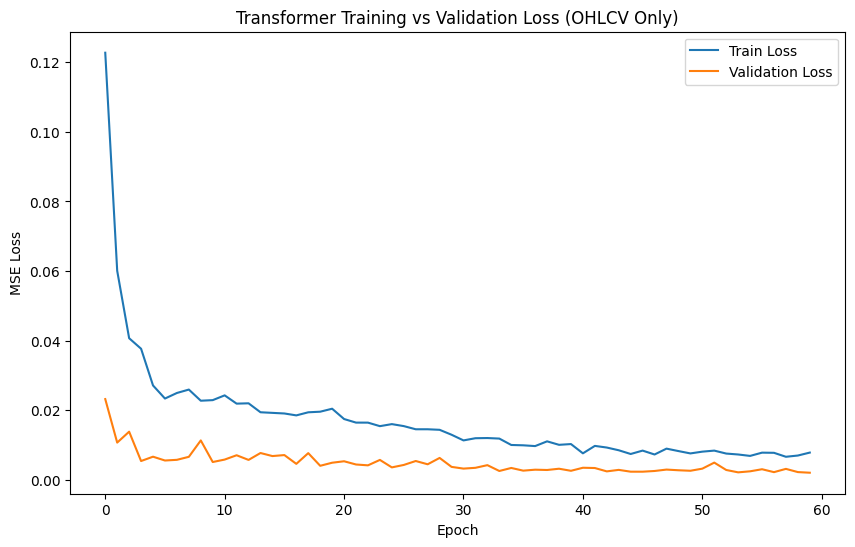

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step


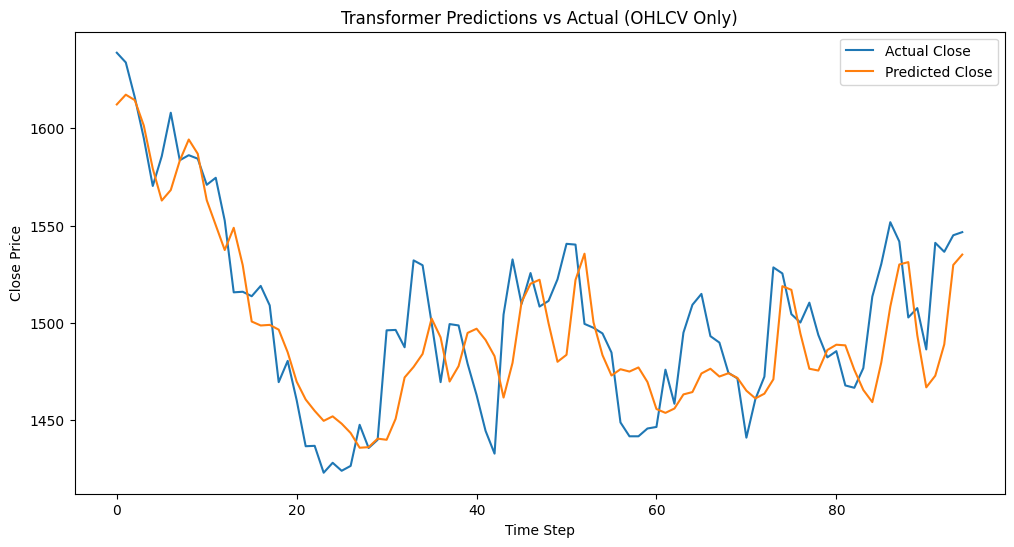

✅ Model saved as transformer_ohlcv_only.h5


In [2]:
# ============================================
# 📘 Transformer Model for Stock Prediction (OHLCV Only)
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, Model
from sklearn.preprocessing import MinMaxScaler
from google.colab import files

# -------------------------------
# 1️⃣ Load Data
# -------------------------------
print("Please upload your stock data CSV file.")
try:
    uploaded = files.upload()
    file_name = list(uploaded.keys())[0]
    df = pd.read_csv(file_name)
except Exception as e:
    print(f"Error loading file: {e}. Please ensure you uploaded a file.")
    # Exit if file upload fails
    raise

print("Original Data Sample:")
print(df.head())

# Drop empty if exists
df = df.drop(columns=['empty'], errors='ignore')

# Convert date and sort
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

# -------------------------------
# 2️⃣ Indicator Removal and Data Filtering
# -------------------------------
# --- MODIFICATION: REMOVED INDICATOR CALCULATION ---
# Only keeping the base OHLCV features.
df = df[['date', 'open', 'high', 'low', 'close', 'volume']].dropna().reset_index(drop=True)

print("\nData with ONLY Base Features (OHLCV):")
print(df.head())

# -------------------------------
# 3️⃣ Prepare Features
# -------------------------------
# --- MODIFICATION: FEATURE LIST REDUCED ---
feature_cols = ['open','high','low','close','volume'] # 5 features
data = df[feature_cols].values

scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data)

def create_sequences(dataset, seq_len=20):
    X, y = [], []
    # CLOSE_INDEX is 3 in the old feature list, but we must recalculate here
    CLOSE_INDEX = feature_cols.index('close') # Should be 3
    for i in range(len(dataset)-seq_len):
        X.append(dataset[i:i+seq_len])
        y.append(dataset[i+seq_len, CLOSE_INDEX])   # predict next 'close'
    return np.array(X), np.array(y)

SEQ_LEN = 20
X, y = create_sequences(data_scaled, SEQ_LEN)

split = int(0.8*len(X))
X_train, y_train = X[:split], y[:split]
X_val, y_val = X[split:], y[split:]

print(f"Train: {X_train.shape}, Validation: {X_val.shape}")

# -------------------------------
# 4️⃣ Build Transformer Model
# -------------------------------
# Positional encoding
def positional_encoding(seq_len, d_model):
    pos = np.arange(seq_len)[:, np.newaxis]
    i = np.arange(d_model)[np.newaxis, :]
    angle_rates = 1 / np.power(10000, (2*(i//2))/np.float32(d_model))
    angle_rads = pos * angle_rates
    pe = np.zeros((seq_len, d_model))
    pe[:, 0::2] = np.sin(angle_rads[:, 0::2])
    pe[:, 1::2] = np.cos(angle_rads[:, 1::2])
    return tf.cast(pe[np.newaxis, ...], dtype=tf.float32)

class TransformerEncoder(layers.Layer):
    def __init__(self, embed_dim, num_heads, ff_dim, rate=0.1):
        super().__init__()
        self.att = layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)
        self.ffn = tf.keras.Sequential([
            layers.Dense(ff_dim, activation="relu"),
            layers.Dense(embed_dim),
        ])
        self.layernorm1 = layers.LayerNormalization(epsilon=1e-6)
        self.layernorm2 = layers.LayerNormalization(epsilon=1e-6)
        self.dropout1 = layers.Dropout(rate)
        self.dropout2 = layers.Dropout(rate)

    def call(self, inputs, training=None):
        attn_output = self.att(inputs, inputs)
        attn_output = self.dropout1(attn_output, training=training)
        out1 = self.layernorm1(inputs + attn_output)
        ffn_output = self.ffn(out1)
        ffn_output = self.dropout2(ffn_output, training=training)
        return self.layernorm2(out1 + ffn_output)

# Hyperparameters
# --- MODIFICATION: embed_dim IS NOW 5 ---
embed_dim = X_train.shape[2]      # input feature dimension (5 features: OHLCV)
num_heads = 4
ff_dim = 64
drop_rate = 0.1

inputs = layers.Input(shape=(SEQ_LEN, embed_dim))
pos_encoding = positional_encoding(SEQ_LEN, embed_dim)
x = inputs + pos_encoding
x = TransformerEncoder(embed_dim, num_heads, ff_dim, rate=drop_rate)(x)
x = TransformerEncoder(embed_dim, num_heads, ff_dim, rate=drop_rate)(x)
x = layers.GlobalAveragePooling1D()(x)
x = layers.Dropout(0.2)(x)
x = layers.Dense(64, activation="relu")(x)
x = layers.Dropout(0.1)(x)
outputs = layers.Dense(1)(x)

model = Model(inputs, outputs)
model.compile(optimizer='adam', loss='mse')
model.summary()

# -------------------------------
# 5️⃣ Train
# -------------------------------
EPOCHS = 60
BATCH_SIZE = 16

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1
)

# -------------------------------
# 6️⃣ Plot Loss 📉
# -------------------------------
plt.figure(figsize=(10,6))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Transformer Training vs Validation Loss (OHLCV Only)")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.show()

# -------------------------------
# 7️⃣ Predictions 📊
# -------------------------------
y_pred = model.predict(X_val)
CLOSE_INDEX = feature_cols.index('close') # Must use the current index (3)

# Inverse scaling for predictions
# The dummy array size is 5, matching the number of features.
dummy = np.zeros((len(y_pred), data.shape[1]))
dummy[:, CLOSE_INDEX] = y_pred[:, 0]
pred_close = scaler.inverse_transform(dummy)[:, CLOSE_INDEX]

# Inverse scaling for actual values
dummy2 = np.zeros((len(y_val), data.shape[1]))
dummy2[:, CLOSE_INDEX] = y_val
actual_close = scaler.inverse_transform(dummy2)[:, CLOSE_INDEX]

plt.figure(figsize=(12, 6))
plt.plot(actual_close, label='Actual Close')
plt.plot(pred_close, label='Predicted Close')
plt.title("Transformer Predictions vs Actual (OHLCV Only)")
plt.xlabel("Time Step")
plt.ylabel("Close Price")
plt.legend()
plt.show()

# -------------------------------
# 8️⃣ Save Model
# -------------------------------
model.save("transformer_ohlcv_only.h5")
print("✅ Model saved as transformer_ohlcv_only.h5")

## With Transformers with Indicators

| Model           | Strength                               | Weakness                    | When to Use                |
| --------------- | -------------------------------------- | --------------------------- | -------------------------- |
| **GRU**         | Light & fast                           | May miss long-term patterns | Quick prototypes           |
| **LSTM**        | Strong memory                          | Slightly slower             | Stable trends              |
| **Transformer** | Handles long-range relations, scalable | Heavier, needs more data    | Advanced / larger datasets |


Saving INFY.csv to INFY (4).csv
Original Data Sample:
                       date     open     high      low    close   volume  \
0  2023-01-02T00:00:00+0530  1514.00  1526.50  1504.05  1524.00  3801140   
1  2023-01-03T00:00:00+0530  1519.85  1532.65  1515.10  1522.55  4551130   
2  2023-01-04T00:00:00+0530  1521.00  1521.00  1491.10  1494.80  7059590   
3  2023-01-05T00:00:00+0530  1505.90  1505.90  1469.25  1475.20  9868404   
4  2023-01-06T00:00:00+0530  1470.00  1475.00  1446.50  1448.50  6443714   

   empty  
0      0  
1      0  
2      0  
3      0  
4      0  

Data with Indicators:
                       date    open     high      low    close   volume  \
0 2023-01-19 00:00:00+05:30  1539.9  1549.55  1526.15  1538.90  6165284   
1 2023-01-20 00:00:00+05:30  1538.0  1545.00  1524.00  1525.55  6496429   
2 2023-01-23 00:00:00+05:30  1535.0  1553.30  1528.10  1548.00  4855020   
3 2023-01-24 00:00:00+05:30  1560.0  1568.80  1549.75  1551.90  5200802   
4 2023-01-25 00:00:00+05:

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 20, 10)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ add_1 (Add)                     │ (None, 20, 10)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_encoder_1           │ (None, 20, 10)         │         3,124 │
│ (TransformerEncoder)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_encoder_2           │ (None, 20, 10)         │         3,124 │
│ (TransformerEncoder)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 10)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 10)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 64)             │           704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,017 (27.41 KB)

 Trainable params: 7,017 (27.41 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/60
33/33 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - loss: 0.1732 - val_loss: 0.0073
Epoch 2/60
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0465 - val_loss: 0.0053
Epoch 3/60
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0286 - val_loss: 0.0064
Epoch 4/60
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0191 - val_loss: 0.0126
Epoch 5/60
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0180 - val_loss: 0.0184
Epoch 6/60
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0144 - val_loss: 0.0102
Epoch 7/60
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0136 - val_loss: 0.0068
Epoch 8/60
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0141 - val_loss: 0.0044
Epoch 9/60
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0120 - val_loss: 0.0085
Epoch 10/60
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0115 - val_loss: 0.0119
Epoch 11/60
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0075 - val_loss: 0.0069
Epoch 12/60
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0094 - val

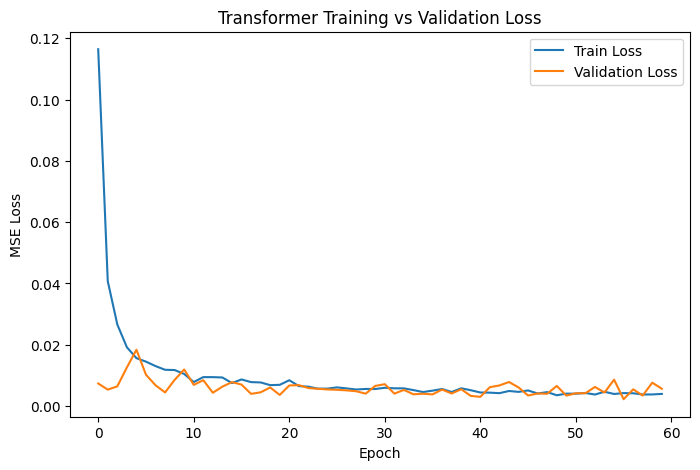

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step


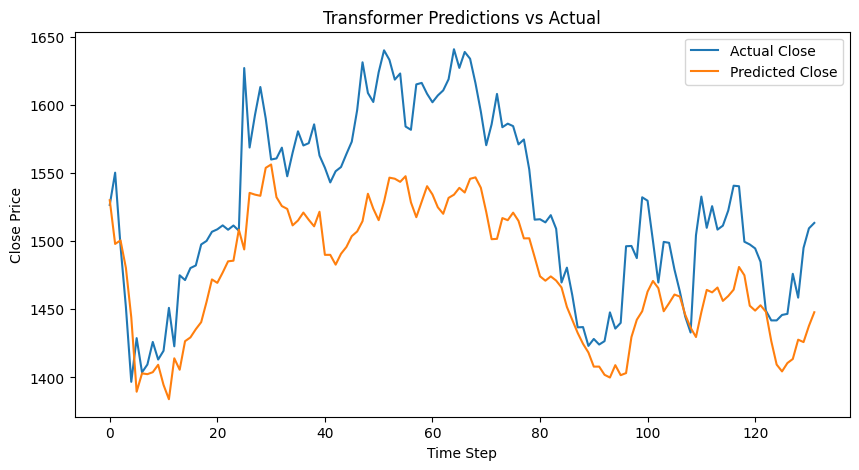

✅ Model saved as transformer_stock_model.h5


In [ ]:
# ============================================
# 📘 Transformer Model for Stock Prediction
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, Model
from sklearn.preprocessing import MinMaxScaler

# -------------------------------
# 1️⃣ Load Data
# -------------------------------
from google.colab import files
uploaded = files.upload()

file_name = list(uploaded.keys())[0]
df = pd.read_csv(file_name)
print("Original Data Sample:")
print(df.head())

# Drop empty if exists
df = df.drop(columns=['empty'], errors='ignore')

# Convert date and sort
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date')

# -------------------------------
# 2️⃣ Add Technical Indicators
# -------------------------------
df['EMA12'] = df['close'].ewm(span=12, adjust=False).mean()
df['EMA26'] = df['close'].ewm(span=26, adjust=False).mean()

def compute_RSI(series, period=14):
    delta = series.diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=period).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=period).mean()
    RS = gain / (loss + 1e-9)
    return 100 - (100 / (1 + RS))

df['RSI'] = compute_RSI(df['close'])

high_low = df['high'] - df['low']
high_close = np.abs(df['high'] - df['close'].shift())
low_close = np.abs(df['low'] - df['close'].shift())
TR = pd.concat([high_low, high_close, low_close], axis=1).max(axis=1)
df['ATR'] = TR.rolling(window=14).mean()

df['OBV'] = (np.sign(df['close'].diff()) * df['volume']).fillna(0).cumsum()
df = df.dropna().reset_index(drop=True)
print("\nData with Indicators:")
print(df.head())

# -------------------------------
# 3️⃣ Prepare Features
# -------------------------------
feature_cols = [
    'open','high','low','close','volume',
    'EMA12','EMA26','RSI','ATR','OBV'
]
data = df[feature_cols].values

scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data)

def create_sequences(dataset, seq_len=20):
    X, y = [], []
    for i in range(len(dataset)-seq_len):
        X.append(dataset[i:i+seq_len])
        y.append(dataset[i+seq_len,3])   # predict next 'close'
    return np.array(X), np.array(y)

SEQ_LEN = 20
X, y = create_sequences(data_scaled, SEQ_LEN)

split = int(0.8*len(X))
X_train, y_train = X[:split], y[:split]
X_val, y_val = X[split:], y[split:]

print(f"Train: {X_train.shape}, Validation: {X_val.shape}")

# -------------------------------
# 4️⃣ Build Transformer Model
# -------------------------------
# Positional encoding
def positional_encoding(seq_len, d_model):
    pos = np.arange(seq_len)[:, np.newaxis]
    i = np.arange(d_model)[np.newaxis, :]
    angle_rates = 1 / np.power(10000, (2*(i//2))/np.float32(d_model))
    angle_rads = pos * angle_rates
    pe = np.zeros((seq_len, d_model))
    pe[:, 0::2] = np.sin(angle_rads[:, 0::2])
    pe[:, 1::2] = np.cos(angle_rads[:, 1::2])
    return tf.cast(pe[np.newaxis, ...], dtype=tf.float32)

class TransformerEncoder(layers.Layer):
    def __init__(self, embed_dim, num_heads, ff_dim, rate=0.1):
        super().__init__()
        self.att = layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)
        self.ffn = tf.keras.Sequential([
            layers.Dense(ff_dim, activation="relu"),
            layers.Dense(embed_dim),
        ])
        self.layernorm1 = layers.LayerNormalization(epsilon=1e-6)
        self.layernorm2 = layers.LayerNormalization(epsilon=1e-6)
        self.dropout1 = layers.Dropout(rate)
        self.dropout2 = layers.Dropout(rate)

    def call(self, inputs, training=None):  # ✅ Default training=None added
        attn_output = self.att(inputs, inputs)
        attn_output = self.dropout1(attn_output, training=training)
        out1 = self.layernorm1(inputs + attn_output)
        ffn_output = self.ffn(out1)
        ffn_output = self.dropout2(ffn_output, training=training)
        return self.layernorm2(out1 + ffn_output)

# Hyperparameters
embed_dim = X_train.shape[2]     # input feature dimension
num_heads = 4
ff_dim = 64
drop_rate = 0.1

inputs = layers.Input(shape=(SEQ_LEN, embed_dim))
pos_encoding = positional_encoding(SEQ_LEN, embed_dim)
x = inputs + pos_encoding
x = TransformerEncoder(embed_dim, num_heads, ff_dim, rate=drop_rate)(x)
x = TransformerEncoder(embed_dim, num_heads, ff_dim, rate=drop_rate)(x)
x = layers.GlobalAveragePooling1D()(x)
x = layers.Dropout(0.2)(x)
x = layers.Dense(64, activation="relu")(x)
x = layers.Dropout(0.1)(x)
outputs = layers.Dense(1)(x)

model = Model(inputs, outputs)
model.compile(optimizer='adam', loss='mse')
model.summary()

# -------------------------------
# 5️⃣ Train
# -------------------------------
EPOCHS = 60
BATCH_SIZE = 16

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1
)

# -------------------------------
# 6️⃣ Plot Loss
# -------------------------------
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Transformer Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.show()

# -------------------------------
# 7️⃣ Predictions
# -------------------------------
y_pred = model.predict(X_val)
dummy = np.zeros((len(y_pred), data.shape[1]))
dummy[:,3] = y_pred[:,0]
pred_close = scaler.inverse_transform(dummy)[:,3]

dummy2 = np.zeros((len(y_val), data.shape[1]))
dummy2[:,3] = y_val
actual_close = scaler.inverse_transform(dummy2)[:,3]

plt.figure(figsize=(10,5))
plt.plot(actual_close, label='Actual Close')
plt.plot(pred_close, label='Predicted Close')
plt.title("Transformer Predictions vs Actual")
plt.xlabel("Time Step")
plt.ylabel("Close Price")
plt.legend()
plt.show()

# -------------------------------
# 8️⃣ Save Model
# -------------------------------
model.save("transformer_stock_model.h5")
print("✅ Model saved as transformer_stock_model.h5")


## CNN-LSTM without Indicators

Please upload your stock data CSV file now.


Saving INFY.csv to INFY (3).csv
Successfully loaded file: INFY (3).csv


Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 15, 5)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 15, 64)         │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 15, 64)         │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 48,513 (189.50 KB)

 Trainable params: 48,513 (189.50 KB)

 Non-trainable params: 0 (0.00 B)


Starting model training...
Epoch 1/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 0.1380 - mae: 0.2754 - val_loss: 0.0094 - val_mae: 0.0799
Epoch 2/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0219 - mae: 0.1157 - val_loss: 0.0042 - val_mae: 0.0556
Epoch 3/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0181 - mae: 0.1005 - val_loss: 0.0034 - val_mae: 0.0492
Epoch 4/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0162 - mae: 0.0963 - val_loss: 0.0034 - val_mae: 0.0498
Epoch 5/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0180 - mae: 0.0972 - val_loss: 0.0030 - val_mae: 0.0460
Epoch 6/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0140 - mae: 0.0896 - val_loss: 0.0028 - val_mae: 0.0448
Epoch 7/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0127 - mae: 0.0852 - val_loss: 0.0029 - val_mae: 0.0449
Epoch 8/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0123 - mae: 0.0832 - val_loss: 0.0035 - val_mae: 0.0514
Epoch 9/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 8m


Test Loss (MSE): 0.001787
Test MAE (Normalized): 0.033655
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step 
Test MAE (Original Price Unit): $20.3964


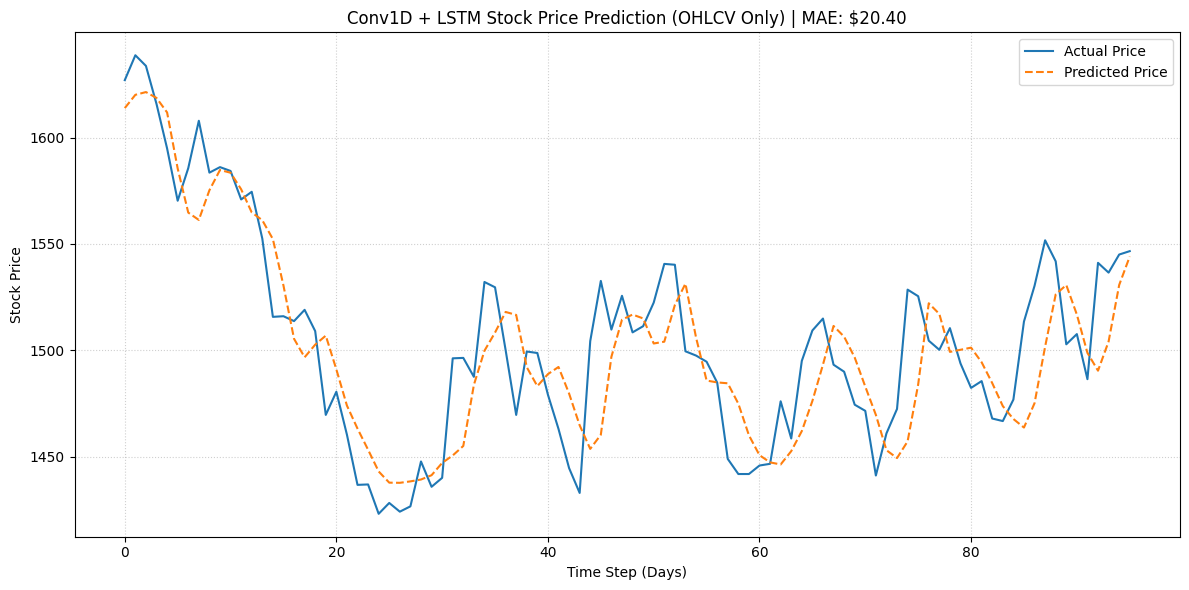

In [4]:
# ============================================
# 📘 Conv1D + LSTM Hybrid Stock Predictor (OHLCV Only)
# ============================================

# Install dependencies (removed 'ta' as it's not needed)
!pip install pandas numpy scikit-learn tensorflow --quiet

# ============================================
# 📂 Imports
# ============================================
import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers, models, callbacks

# ============================================
# 📈 Load & Prepare Data (Assumes a 'date', 'open', 'high', 'low', 'close', 'volume' format)
# ============================================
# Use this block if running in Google Colab to upload your CSV file
from google.colab import files
import io

print("Please upload your stock data CSV file now.")
uploaded = files.upload()

# Automatically pick the first uploaded file
filename = list(uploaded.keys())[0]
df = pd.read_csv(io.StringIO(uploaded[filename].decode('utf-8')))
print(f"Successfully loaded file: {filename}")

# Clean and sort
df = df.dropna()
# Ensure column names are lowercase for consistency if they weren't already
df.columns = [col.lower() for col in df.columns]
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date')

# ============================================
# ⚙️ Feature Selection & Scaling (OHLCV ONLY)
# ============================================
# *** Features reduced to only raw OHLCV data ***
features = ['open', 'high', 'low', 'close', 'volume']
target = 'close'

# Drop rows with any NaN values that might have remained
df = df[features].dropna()

# Initialize and fit the scaler
scaler = MinMaxScaler()
# Apply scaling only to the selected features
df_scaled = scaler.fit_transform(df[features].values)

# Create a separate scaler for the target variable (Close) for easy inverse transformation later
target_scaler = MinMaxScaler()
target_scaler.fit(df[target].values.reshape(-1, 1))

# ============================================
# 🧩 Sequence Creation
# ============================================
SEQ_LEN = 15  # Number of past days to use as input

def create_sequences(data, target_col_index, seq_len):
    """
    Creates sequences for the training set (X) and the next day's target (y).
    """
    X, y = [], []
    for i in range(len(data) - seq_len):
        # X is the sequence of features for SEQ_LEN days
        X.append(data[i:i+seq_len])
        # y is the target value (closing price) on the day after the sequence ends
        y.append(data[i+seq_len, target_col_index])
    return np.array(X), np.array(y)

# Get the index of the 'close' column in the features list (will be 3)
target_index = features.index(target)

# Create the sequences using the scaled data
X, y = create_sequences(df_scaled, target_index, SEQ_LEN)

# Split train/test (80% train, 20% test)
# Shuffle=False is crucial for time series data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# ============================================
# 🧱 Build Conv1D + LSTM Model
# ============================================
def build_cnn_lstm(seq_len, n_features):
    """
    Builds the hybrid Conv1D and LSTM model.
    """
    inputs = layers.Input(shape=(seq_len, n_features))
    # Conv1D layers process local patterns in the sequence
    x = layers.Conv1D(filters=64, kernel_size=3, activation='relu', padding='causal')(inputs)
    x = layers.Conv1D(filters=64, kernel_size=3, activation='relu', padding='causal')(x)
    # LSTM layer processes the sequence data captured by Conv1D
    x = layers.LSTM(units=64, return_sequences=False)(x)
    x = layers.Dense(32, activation='relu')(x)
    x = layers.Dropout(0.2)(x)
    # Output layer predicts the single normalized closing price
    outputs = layers.Dense(1)(x)
    model = models.Model(inputs, outputs)
    return model

# X_train.shape[2] will be 5, the number of features (OHLCV)
model = build_cnn_lstm(SEQ_LEN, X_train.shape[2])

# Compile
model.compile(optimizer='adam', loss='mse', metrics=['mae'])
model.summary()

# ============================================
# 🏋️ Train
# ============================================
print("\nStarting model training...")

# Add EarlyStopping for robust training
early_stopping = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=50, # Increased epochs but relying on EarlyStopping
    batch_size=16,
    callbacks=[early_stopping],
    verbose=1
)

# ============================================
# 📊 Evaluate & Inverse Transform
# ============================================
loss, mae = model.evaluate(X_test, y_test, verbose=0)
print(f"\nTest Loss (MSE): {loss:.6f}")
print(f"Test MAE (Normalized): {mae:.6f}")

# Predict
preds_normalized = model.predict(X_test)

# Inverse transform predictions and actual values to the original price scale
y_test_original = target_scaler.inverse_transform(y_test.reshape(-1, 1))
preds_original = target_scaler.inverse_transform(preds_normalized)

# Calculate MAE in original currency/price unit
mae_original = np.mean(np.abs(y_test_original - preds_original))
# FIX: Removed the [0] index as np.mean returns a scalar, not an array.
print(f"Test MAE (Original Price Unit): ${mae_original:.4f}")

# ============================================
# 🔮 Plot Results
# ============================================
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
# Plotting the original price values
plt.plot(y_test_original, label="Actual Price", color='#1f77b4')
plt.plot(preds_original, label="Predicted Price", color='#ff7f0e', linestyle='--')

# Note: The MAE is a single scalar value, so we access it directly
plt.title(f"Conv1D + LSTM Stock Price Prediction (OHLCV Only) | MAE: ${mae_original:.2f}")
plt.xlabel("Time Step (Days)")
plt.ylabel("Stock Price")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

## Conv1D + LSTM Hybrid for Stock Forecasting

Input → Conv1D(64) → Conv1D(64) → LSTM(64)
      → Dense(32) → Dropout(0.2) → Dense(1)

  Preparing metadata (setup.py) ... done


Saving INFY.csv to INFY (5).csv


/tmp/ipython-input-596378734.py:45: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='bfill').fillna(method='ffill')


Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)      │ (None, 15, 10)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 15, 64)         │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 15, 64)         │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 49,473 (193.25 KB)

 Trainable params: 49,473 (193.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - loss: 0.0400 - mae: 0.1452 - val_loss: 0.0033 - val_mae: 0.0433
Epoch 2/30
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0150 - mae: 0.0887 - val_loss: 0.0034 - val_mae: 0.0448
Epoch 3/30
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0135 - mae: 0.0827 - val_loss: 0.0031 - val_mae: 0.0430
Epoch 4/30
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0087 - mae: 0.0666 - val_loss: 0.0061 - val_mae: 0.0666
Epoch 5/30
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0101 - mae: 0.0737 - val_loss: 0.0023 - val_mae: 0.0363
Epoch 6/30
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0085 - mae: 0.0692 - val_loss: 0.0027 - val_mae: 0.0421
Epoch 7/30
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0079 - mae: 0.0671 - val_loss: 0.0027 - val_mae: 0.0392
Epoch 8/30
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0066 - mae: 0.0614 - val_loss: 0.0023 - val_mae: 0.0365
Epoch 9/30
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0060 - mae:

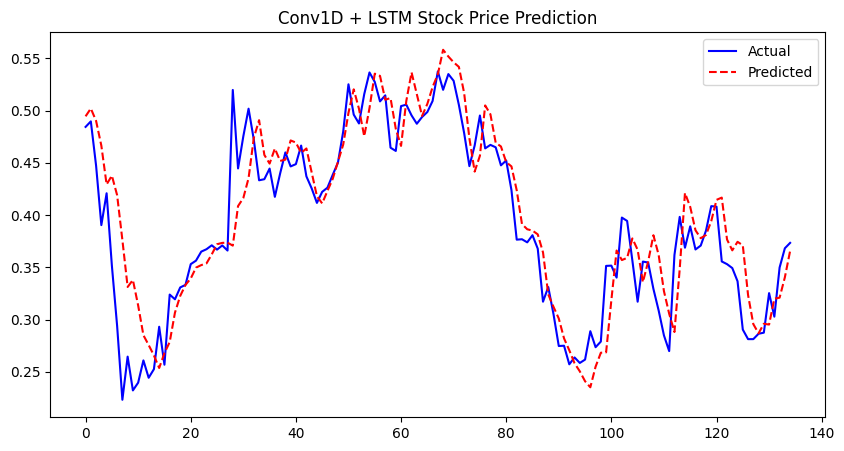

In [ ]:
# ============================================
# 📘 Conv1D + LSTM Hybrid Stock Predictor
# ============================================

# Install dependencies
!pip install pandas numpy scikit-learn tensorflow ta --quiet

# ============================================
# 📂 Imports
# ============================================
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras import layers, models
import ta  # technical indicators

# ============================================
# 📈 Load & Prepare Data
# ============================================
# Replace with your CSV file path or upload via Colab file picker
from google.colab import files
uploaded = files.upload()

# Example: automatically pick first uploaded file
filename = list(uploaded.keys())[0]
df = pd.read_csv(filename)

# Clean and sort
df = df.dropna()
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date')

# ============================================
# 📊 Add Technical Indicators
# ============================================
df['rsi'] = ta.momentum.RSIIndicator(df['close']).rsi()
df['ema_10'] = ta.trend.EMAIndicator(df['close'], window=10).ema_indicator()
df['ema_20'] = ta.trend.EMAIndicator(df['close'], window=20).ema_indicator()
df['macd'] = ta.trend.MACD(df['close']).macd()
df['stoch'] = ta.momentum.StochasticOscillator(df['high'], df['low'], df['close']).stoch()

# Fill missing values after indicator calculation
df = df.fillna(method='bfill').fillna(method='ffill')

# ============================================
# ⚙️ Feature Selection & Scaling
# ============================================
features = ['open', 'high', 'low', 'close', 'volume', 'rsi', 'ema_10', 'ema_20', 'macd', 'stoch']
target = 'close'

scaler = MinMaxScaler()
df[features] = scaler.fit_transform(df[features])

# ============================================
# 🧩 Sequence Creation
# ============================================
SEQ_LEN = 15  # Number of past days to use as input

def create_sequences(data, target_col, seq_len):
    X, y = [], []
    for i in range(len(data) - seq_len):
        X.append(data[i:i+seq_len])
        y.append(data[i+seq_len, target_col])
    return np.array(X), np.array(y)

data = df[features].values
target_index = features.index(target)
X, y = create_sequences(data, target_index, SEQ_LEN)

# Split train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# ============================================
# 🧱 Build Conv1D + LSTM Model
# ============================================
def build_cnn_lstm(seq_len, n_features):
    inputs = layers.Input(shape=(seq_len, n_features))
    x = layers.Conv1D(64, 3, activation='relu', padding='causal')(inputs)
    x = layers.Conv1D(64, 3, activation='relu', padding='causal')(x)
    x = layers.LSTM(64, return_sequences=False)(x)
    x = layers.Dense(32, activation='relu')(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(1)(x)
    model = models.Model(inputs, outputs)
    return model

model = build_cnn_lstm(SEQ_LEN, X_train.shape[2])

# Compile
model.compile(optimizer='adam', loss='mse', metrics=['mae'])
model.summary()

# ============================================
# 🏋️ Train
# ============================================
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=30,
    batch_size=16,
    verbose=1
)

# ============================================
# 📊 Evaluate
# ============================================
loss, mae = model.evaluate(X_test, y_test)
print(f"Test MAE: {mae:.4f}")

# ============================================
# 🔮 Predict & Compare
# ============================================
preds = model.predict(X_test)

import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
plt.plot(y_test, label="Actual", color='blue')
plt.plot(preds, label="Predicted", color='red', linestyle='--')
plt.title("Conv1D + LSTM Stock Price Prediction")
plt.legend()
plt.show()


## Combine LSTM - CNN model with indicators

Saving INFY.csv to INFY (1).csv
                       date     open     high      low    close   volume
0 2023-01-02 00:00:00+05:30  1514.00  1526.50  1504.05  1524.00  3801140
1 2023-01-03 00:00:00+05:30  1519.85  1532.65  1515.10  1522.55  4551130
2 2023-01-04 00:00:00+05:30  1521.00  1521.00  1491.10  1494.80  7059590
3 2023-01-05 00:00:00+05:30  1505.90  1505.90  1469.25  1475.20  9868404
4 2023-01-06 00:00:00+05:30  1470.00  1475.00  1446.50  1448.50  6443714

Training for feature set: Set1_Close_MA5_MA20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step


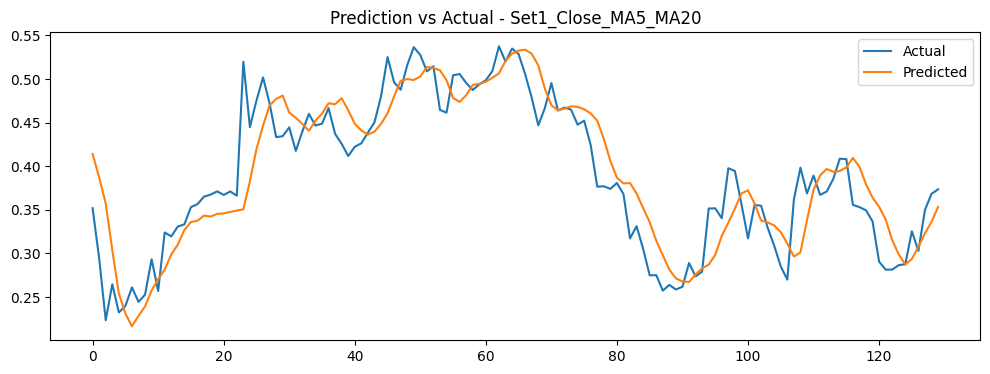


Training for feature set: Set2_Close_EMA10_STD5
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step


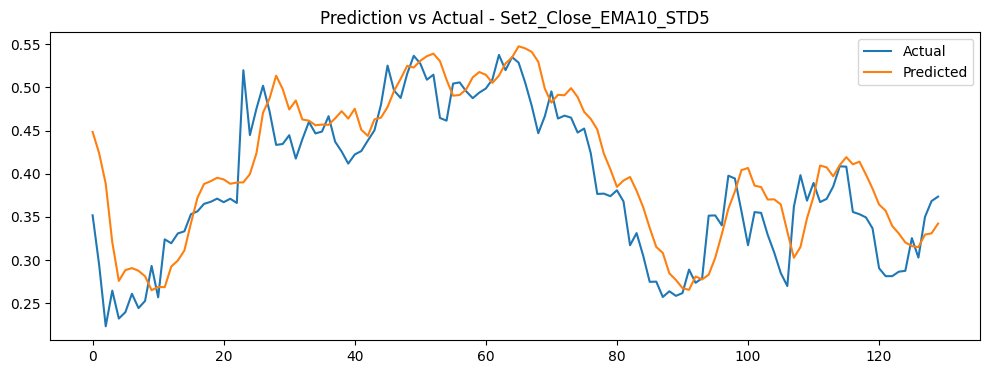


Training for feature set: Set3_Close_Return_STD20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step


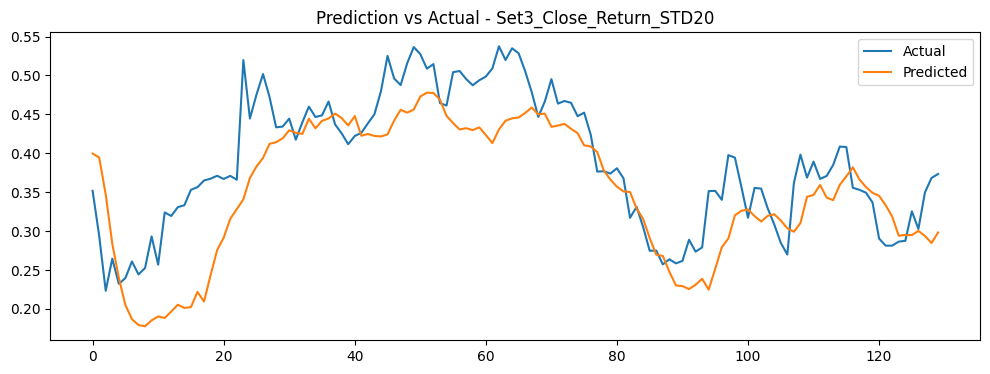

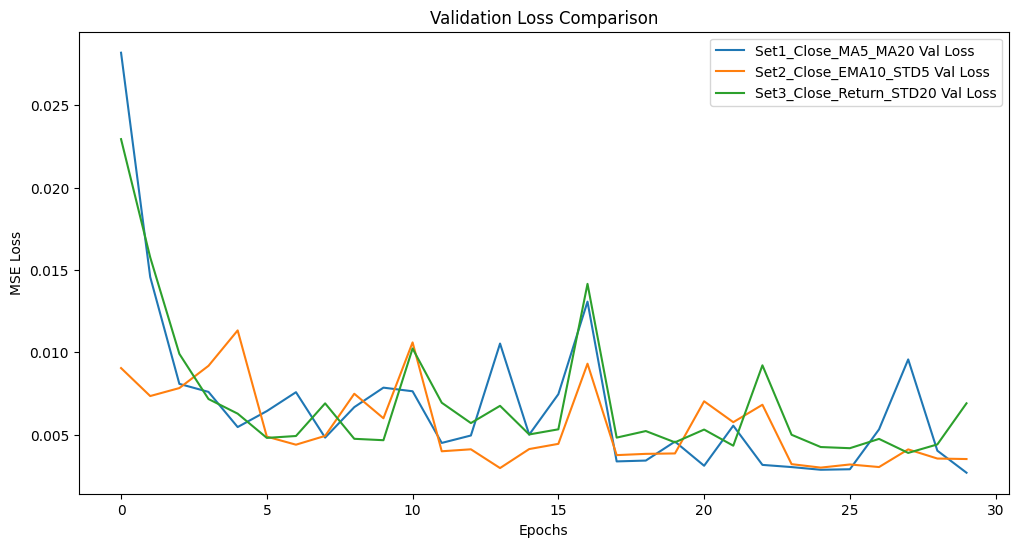

In [ ]:
# Install dependencies
!pip install tensorflow pandas matplotlib scikit-learn

# -------------------------------
# Step 1: Imports
# -------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense, Conv1D, Flatten, Dropout, Concatenate
from google.colab import files

# -------------------------------
# Step 2: Upload CSV
# -------------------------------
uploaded = files.upload()
filename = list(uploaded.keys())[0]

df = pd.read_csv(filename, parse_dates=['date'])
df.sort_values('date', inplace=True)
df.reset_index(drop=True, inplace=True)

# Drop unnecessary columns
df = df[['date','open','high','low','close','volume']]

print(df.head())

# -------------------------------
# Step 3: Create indicators
# -------------------------------
df['MA5'] = df['close'].rolling(5).mean()
df['MA20'] = df['close'].rolling(20).mean()
df['STD5'] = df['close'].rolling(5).std()
df['STD20'] = df['close'].rolling(20).std()
df['EMA10'] = df['close'].ewm(span=10, adjust=False).mean()
df['Return'] = df['close'].pct_change()
df = df.dropna()

# -------------------------------
# Step 4: Define function to create sequences
# -------------------------------
def create_sequences(data, seq_len=20):
    X, y = [], []
    for i in range(seq_len, len(data)):
        X.append(data[i-seq_len:i])
        y.append(data[i, 0])  # Predict 'close'
    return np.array(X), np.array(y)

# -------------------------------
# Step 5: Define function to build LSTM-CNN model
# -------------------------------
def build_model(seq_len, n_features):
    input_layer = Input(shape=(seq_len, n_features))

    # LSTM branch
    lstm_out = LSTM(50, return_sequences=True)(input_layer)
    lstm_out = LSTM(30)(lstm_out)

    # CNN branch
    cnn_out = Conv1D(filters=64, kernel_size=3, activation='relu')(input_layer)
    cnn_out = Conv1D(filters=32, kernel_size=3, activation='relu')(cnn_out)
    cnn_out = Flatten()(cnn_out)

    # Combine
    combined = Concatenate()([lstm_out, cnn_out])
    combined = Dense(50, activation='relu')(combined)
    combined = Dropout(0.2)(combined)
    output = Dense(1)(combined)

    model = Model(inputs=input_layer, outputs=output)
    model.compile(optimizer='adam', loss='mse')
    return model

# -------------------------------
# Step 6: Train with different feature combinations
# -------------------------------
seq_len = 20
feature_sets = {
    'Set1_Close_MA5_MA20': ['close', 'MA5', 'MA20'],
    'Set2_Close_EMA10_STD5': ['close', 'EMA10', 'STD5'],
    'Set3_Close_Return_STD20': ['close', 'Return', 'STD20']
}

results = {}

for name, features in feature_sets.items():
    print(f"\nTraining for feature set: {name}")
    scaler = MinMaxScaler()
    data_scaled = scaler.fit_transform(df[features])

    X, y = create_sequences(data_scaled, seq_len)
    split = int(0.8 * len(X))
    X_train, X_test = X[:split], X[split:]
    y_train, y_test = y[:split], y[split:]

    model = build_model(seq_len, len(features))
    history = model.fit(X_train, y_train, epochs=30, batch_size=32, validation_split=0.2, verbose=0)

    results[name] = history.history
    # Predict
    y_pred = model.predict(X_test)

    plt.figure(figsize=(12,4))
    plt.plot(y_test, label='Actual')
    plt.plot(y_pred, label='Predicted')
    plt.title(f'Prediction vs Actual - {name}')
    plt.legend()
    plt.show()

# -------------------------------
# Step 7: Compare losses
# -------------------------------
plt.figure(figsize=(12,6))
for name, history in results.items():
    plt.plot(history['val_loss'], label=f'{name} Val Loss')
plt.title('Validation Loss Comparison')
plt.xlabel('Epochs')
plt.ylabel('MSE Loss')
plt.legend()
plt.show()


## Different model comparison for Stock indicators

MA5, MA20, STD5, STD20, EMA10, Return

Saving INFY.csv to INFY (4).csv
                       date     open     high      low    close   volume
0 2023-01-02 00:00:00+05:30  1514.00  1526.50  1504.05  1524.00  3801140
1 2023-01-03 00:00:00+05:30  1519.85  1532.65  1515.10  1522.55  4551130
2 2023-01-04 00:00:00+05:30  1521.00  1521.00  1491.10  1494.80  7059590
3 2023-01-05 00:00:00+05:30  1505.90  1505.90  1469.25  1475.20  9868404
4 2023-01-06 00:00:00+05:30  1470.00  1475.00  1446.50  1448.50  6443714
Linear Regression MSE: 0.0011585028625900333
Logistic Regression Accuracy: 0.5692307692307692


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
LSTM MSE: 0.003210628849434834


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
GRU MSE: 0.001119802587499254
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
LSTM-CNN MSE: 0.0031263952491471327
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
Transformer MSE: 0.0072349272298187

Model Comparison:
Linear Regression: 0.0011585028625900333
Logistic Regression Accuracy: 0.5692307692307692
LSTM MSE: 0.003210628849434834
GRU MSE: 0.001119802587499254
LSTM-CNN MSE: 0.0031263952491471327
Transformer MSE: 0.0072349272298187


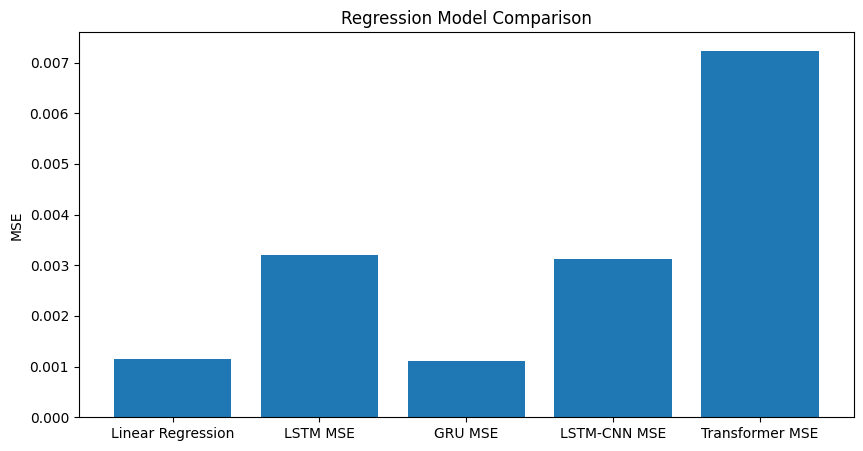

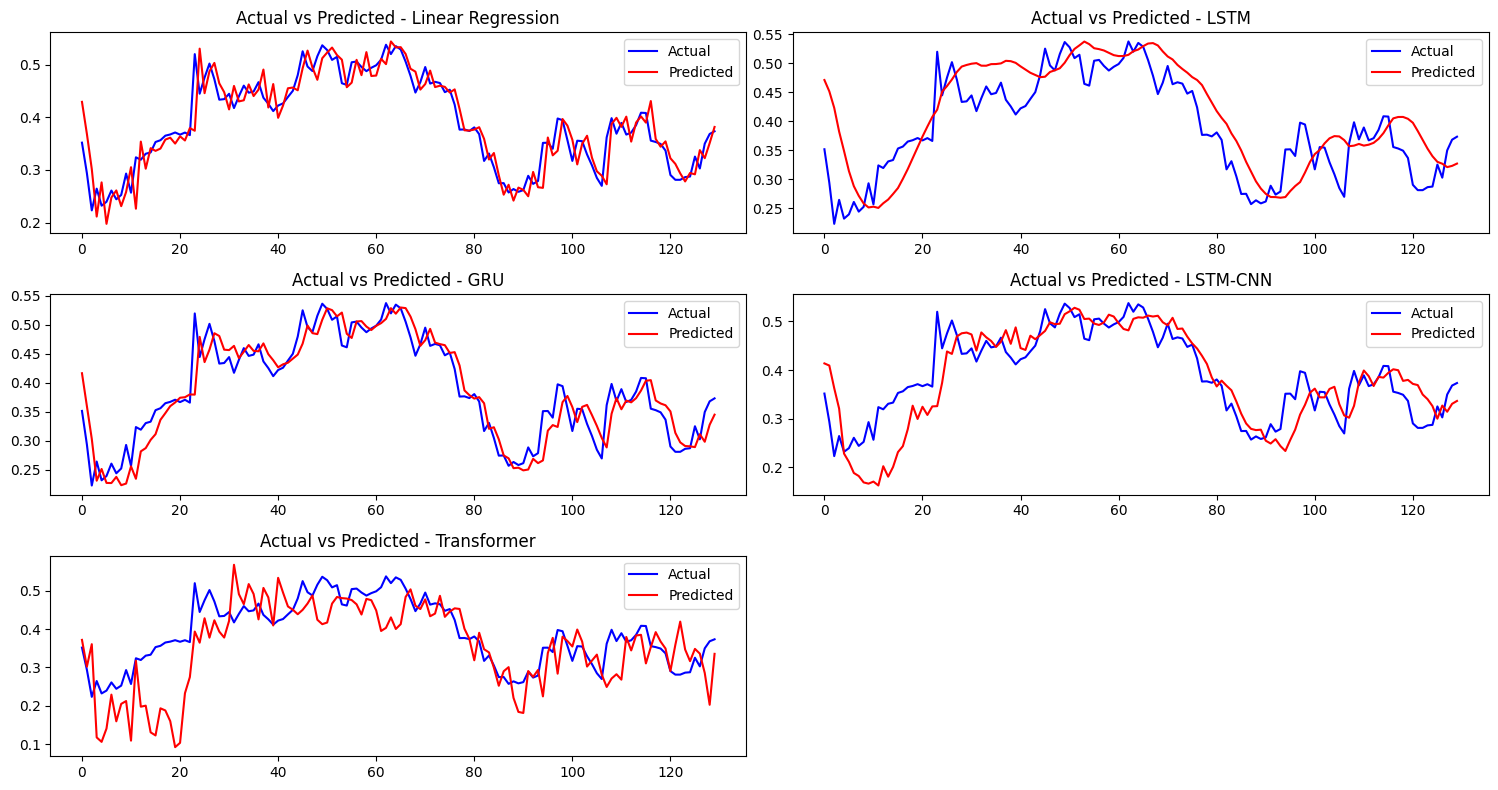

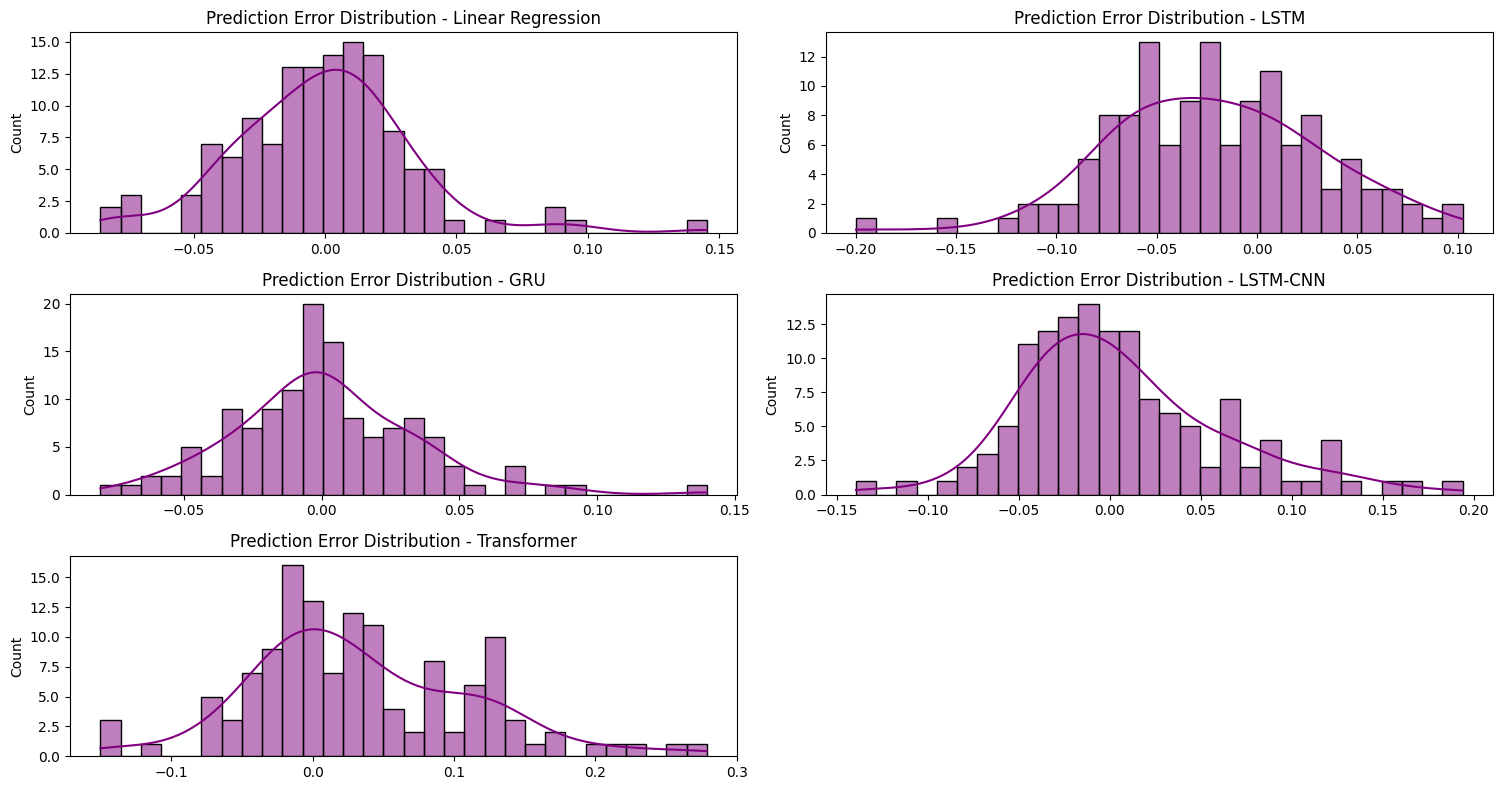

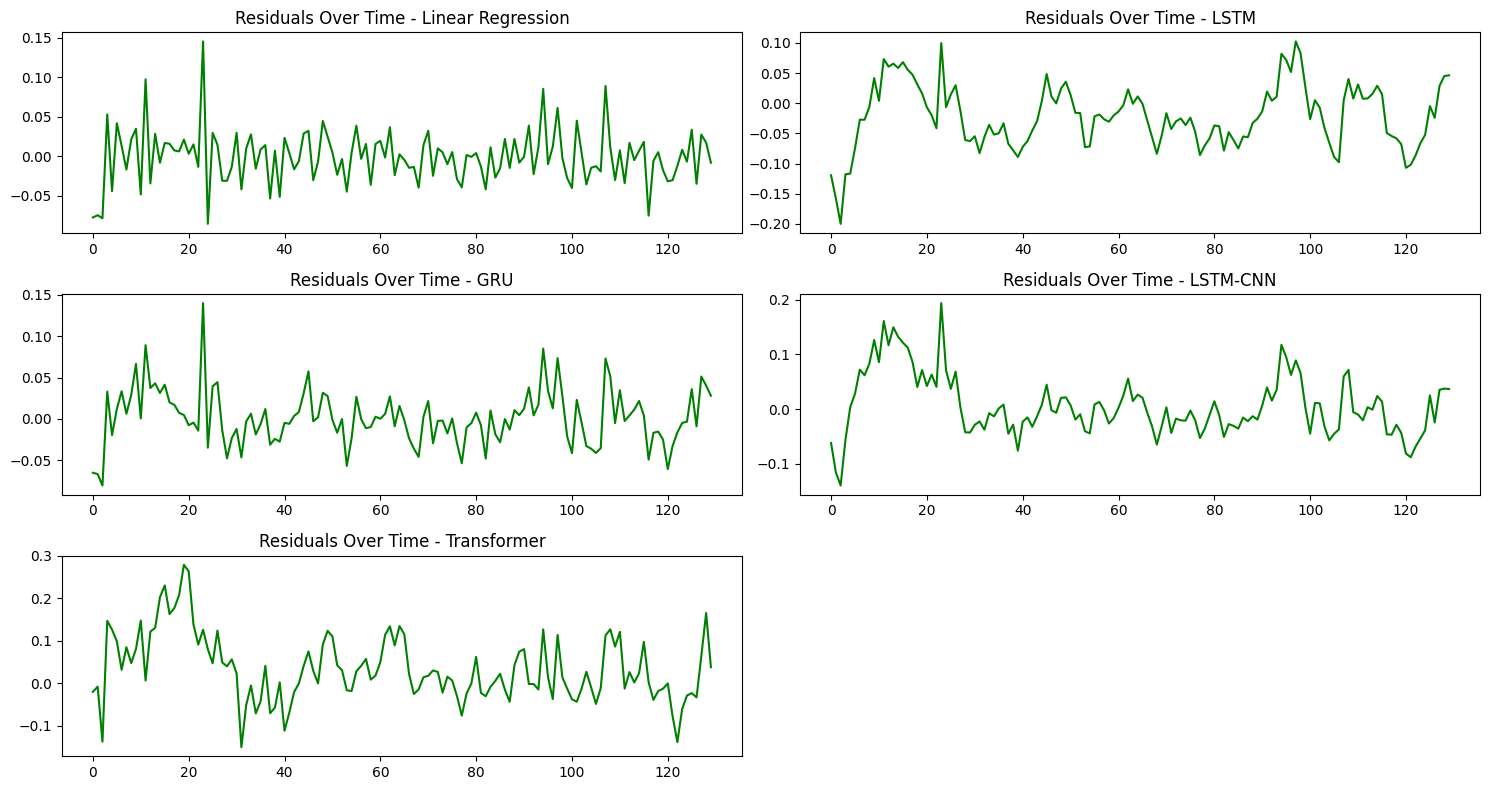

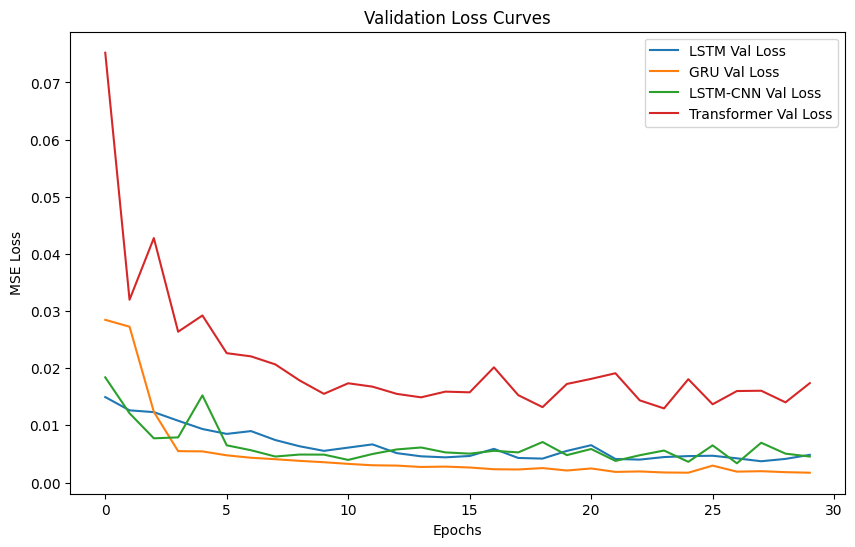

/tmp/ipython-input-2160908534.py:261: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=regression_models, y=mse_values, palette='Set2')


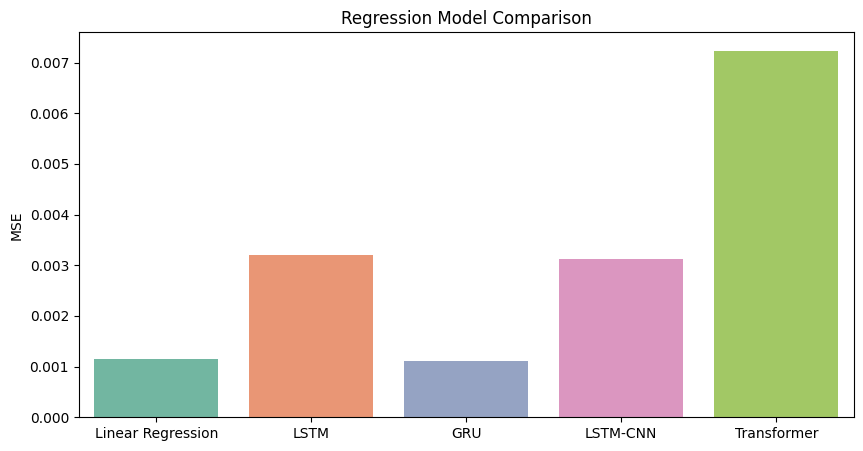

/tmp/ipython-input-2160908534.py:270: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=['Logistic Regression'], y=[results['Logistic Regression Accuracy']], palette='Set1')


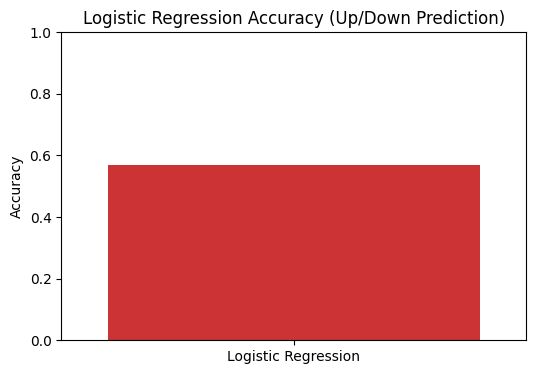

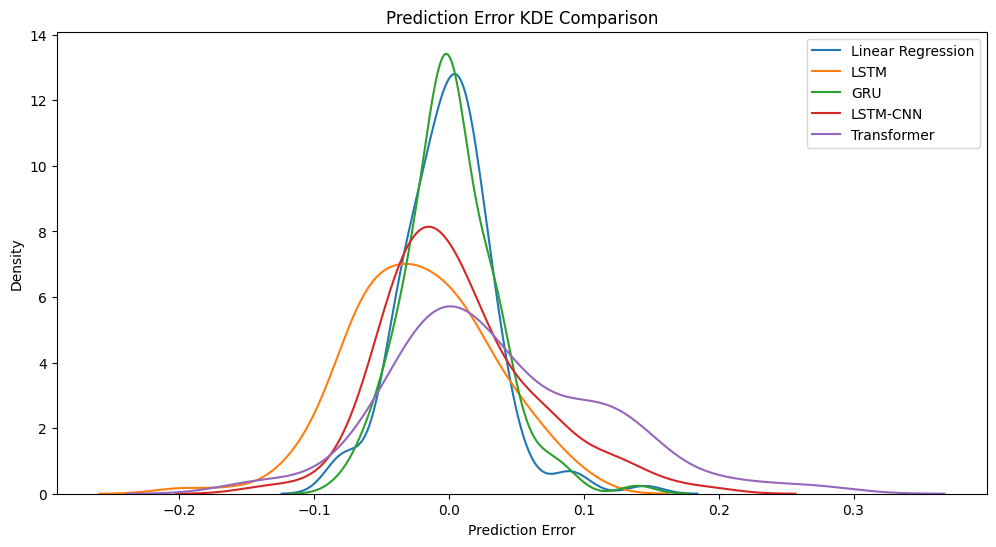

In [ ]:
# Install dependencies
!pip install tensorflow pandas scikit-learn matplotlib

# -------------------------------
# Step 1: Imports
# -------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error, accuracy_score
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Input, LSTM, GRU, Dense, Conv1D, Flatten, Dropout, Concatenate, LayerNormalization, MultiHeadAttention, Add
from google.colab import files

# -------------------------------
# Step 2: Upload CSV
# -------------------------------
uploaded = files.upload()
filename = list(uploaded.keys())[0]

df = pd.read_csv(filename, parse_dates=['date'])
df.sort_values('date', inplace=True)
df.reset_index(drop=True, inplace=True)
df = df[['date','open','high','low','close','volume']]
print(df.head())

# -------------------------------
# Step 3: Indicators
# -------------------------------
df['MA5'] = df['close'].rolling(5).mean()
df['MA20'] = df['close'].rolling(20).mean()
df['STD5'] = df['close'].rolling(5).std()
df['STD20'] = df['close'].rolling(20).std()
df['EMA10'] = df['close'].ewm(span=10, adjust=False).mean()
df['Return'] = df['close'].pct_change()
df = df.dropna()

# -------------------------------
# Step 4: Prepare sequences
# -------------------------------
def create_sequences(data, seq_len=20):
    X, y = [], []
    for i in range(seq_len, len(data)):
        X.append(data[i-seq_len:i])
        y.append(data[i, 0])  # Predict 'close'
    return np.array(X), np.array(y)

# For Logistic Regression: create up/down target
df['UpDown'] = (df['close'].shift(-1) > df['close']).astype(int)
df = df.dropna()

# -------------------------------
# Step 5: Feature selection
# -------------------------------
features = ['close','MA5','MA20','STD5','STD20','EMA10','Return']
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(df[features])
seq_len = 20
X_seq, y_seq = create_sequences(data_scaled, seq_len)
y_lr = df['close'].values[seq_len:]
y_logistic = df['UpDown'].values[seq_len:]

# Train-test split
split = int(0.8 * len(X_seq))
X_train, X_test = X_seq[:split], X_seq[split:]
y_train, y_test = y_seq[:split], y_seq[split:]
y_log_train, y_log_test = y_logistic[:split], y_logistic[split:]

# -------------------------------
# Step 6: Define models
# -------------------------------

def build_lstm(seq_len, n_features):
    model = Sequential()
    model.add(LSTM(50, return_sequences=True, input_shape=(seq_len, n_features)))
    model.add(LSTM(30))
    model.add(Dense(1))
    model.compile(optimizer='adam', loss='mse')
    return model

def build_gru(seq_len, n_features):
    model = Sequential()
    model.add(GRU(50, return_sequences=True, input_shape=(seq_len, n_features)))
    model.add(GRU(30))
    model.add(Dense(1))
    model.compile(optimizer='adam', loss='mse')
    return model

def build_lstm_cnn(seq_len, n_features):
    input_layer = Input(shape=(seq_len, n_features))
    lstm_out = LSTM(50, return_sequences=True)(input_layer)
    lstm_out = LSTM(30)(lstm_out)
    cnn_out = Conv1D(64, 3, activation='relu')(input_layer)
    cnn_out = Conv1D(32, 3, activation='relu')(cnn_out)
    cnn_out = Flatten()(cnn_out)
    combined = Concatenate()([lstm_out, cnn_out])
    combined = Dense(50, activation='relu')(combined)
    combined = Dropout(0.2)(combined)
    output = Dense(1)(combined)
    model = Model(inputs=input_layer, outputs=output)
    model.compile(optimizer='adam', loss='mse')
    return model

def build_transformer(seq_len, n_features, embed_dim=32, num_heads=2):
    input_layer = Input(shape=(seq_len, n_features))
    # Simple transformer block
    attn_output = MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)(input_layer, input_layer)
    attn_output = Add()([input_layer, attn_output])
    out = LayerNormalization()(attn_output)
    out = Flatten()(out)
    out = Dense(64, activation='relu')(out)
    out = Dense(1)(out)
    model = Model(inputs=input_layer, outputs=out)
    model.compile(optimizer='adam', loss='mse')
    return model

# -------------------------------
# Step 7: Train and evaluate
# -------------------------------
results = {}

# Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train.reshape(X_train.shape[0], -1), y_train)
y_pred_lr = lr_model.predict(X_test.reshape(X_test.shape[0], -1))
results['Linear Regression'] = mean_squared_error(y_test, y_pred_lr)
print("Linear Regression MSE:", results['Linear Regression'])

# Logistic Regression (up/down)
log_model = LogisticRegression(max_iter=500)
log_model.fit(X_train.reshape(X_train.shape[0], -1), y_log_train)
y_pred_log = log_model.predict(X_test.reshape(X_test.shape[0], -1))
results['Logistic Regression Accuracy'] = accuracy_score(y_log_test, y_pred_log)
print("Logistic Regression Accuracy:", results['Logistic Regression Accuracy'])

# LSTM
lstm_model = build_lstm(seq_len, X_train.shape[2])
history_lstm = lstm_model.fit(X_train, y_train, epochs=30, batch_size=32, validation_split=0.2, verbose=0)
y_pred_lstm = lstm_model.predict(X_test)
results['LSTM MSE'] = mean_squared_error(y_test, y_pred_lstm)
print("LSTM MSE:", results['LSTM MSE'])

# GRU
gru_model = build_gru(seq_len, X_train.shape[2])
history_gru = gru_model.fit(X_train, y_train, epochs=30, batch_size=32, validation_split=0.2, verbose=0)
y_pred_gru = gru_model.predict(X_test)
results['GRU MSE'] = mean_squared_error(y_test, y_pred_gru)
print("GRU MSE:", results['GRU MSE'])

# LSTM-CNN
lstm_cnn_model = build_lstm_cnn(seq_len, X_train.shape[2])
history_lstm_cnn = lstm_cnn_model.fit(X_train, y_train, epochs=30, batch_size=32, validation_split=0.2, verbose=0)
y_pred_lstm_cnn = lstm_cnn_model.predict(X_test)
results['LSTM-CNN MSE'] = mean_squared_error(y_test, y_pred_lstm_cnn)
print("LSTM-CNN MSE:", results['LSTM-CNN MSE'])

# Transformer
transformer_model = build_transformer(seq_len, X_train.shape[2])
history_transformer = transformer_model.fit(X_train, y_train, epochs=30, batch_size=32, validation_split=0.2, verbose=0)
y_pred_transformer = transformer_model.predict(X_test)
results['Transformer MSE'] = mean_squared_error(y_test, y_pred_transformer)
print("Transformer MSE:", results['Transformer MSE'])

# -------------------------------
# Step 8: Compare results
# -------------------------------
print("\nModel Comparison:")
for k, v in results.items():
    print(f"{k}: {v}")

# Plot MSE for regression models
plt.figure(figsize=(10,5))
regression_models = ['Linear Regression','LSTM MSE','GRU MSE','LSTM-CNN MSE','Transformer MSE']
mse_values = [results[m] for m in regression_models]
plt.bar(regression_models, mse_values)
plt.ylabel('MSE')
plt.title('Regression Model Comparison')
plt.show()

# After all models are trained (keep previous code)

import seaborn as sns

# -------------------------------
# Step 9: Plot Actual vs Predicted for regression models
# -------------------------------
regression_models_preds = {
    'Linear Regression': y_pred_lr,
    'LSTM': y_pred_lstm,
    'GRU': y_pred_gru,
    'LSTM-CNN': y_pred_lstm_cnn,
    'Transformer': y_pred_transformer
}

plt.figure(figsize=(15,8))
for i, (name, y_pred) in enumerate(regression_models_preds.items()):
    plt.subplot(3,2,i+1)
    plt.plot(y_test, label='Actual', color='blue')
    plt.plot(y_pred, label='Predicted', color='red')
    plt.title(f'Actual vs Predicted - {name}')
    plt.legend()
plt.tight_layout()
plt.show()

# -------------------------------
# Step 10: Prediction error distributions
# -------------------------------
plt.figure(figsize=(15,8))
for i, (name, y_pred) in enumerate(regression_models_preds.items()):
    plt.subplot(3,2,i+1)
    errors = y_test - y_pred.flatten()
    sns.histplot(errors, bins=30, kde=True, color='purple')
    plt.title(f'Prediction Error Distribution - {name}')
plt.tight_layout()
plt.show()

# -------------------------------
# Step 11: Residuals over time
# -------------------------------
plt.figure(figsize=(15,8))
for i, (name, y_pred) in enumerate(regression_models_preds.items()):
    plt.subplot(3,2,i+1)
    residuals = y_test - y_pred.flatten()
    plt.plot(residuals, color='green')
    plt.title(f'Residuals Over Time - {name}')
plt.tight_layout()
plt.show()

# -------------------------------
# Step 12: Validation loss curves for deep learning models
# -------------------------------
plt.figure(figsize=(10,6))
plt.plot(history_lstm.history['val_loss'], label='LSTM Val Loss')
plt.plot(history_gru.history['val_loss'], label='GRU Val Loss')
plt.plot(history_lstm_cnn.history['val_loss'], label='LSTM-CNN Val Loss')
plt.plot(history_transformer.history['val_loss'], label='Transformer Val Loss')
plt.title('Validation Loss Curves')
plt.xlabel('Epochs')
plt.ylabel('MSE Loss')
plt.legend()
plt.show()

# -------------------------------
# Step 13: Regression MSE comparison bar chart (fixed)
# -------------------------------
regression_models = ['Linear Regression','LSTM','GRU','LSTM-CNN','Transformer']

# Map results properly
mse_values = [
    results['Linear Regression'],         # Linear Regression stored as plain key
    results['LSTM MSE'],
    results['GRU MSE'],
    results['LSTM-CNN MSE'],
    results['Transformer MSE']
]

# Plot MSE bar chart
plt.figure(figsize=(10,5))
sns.barplot(x=regression_models, y=mse_values, palette='Set2')
plt.ylabel('MSE')
plt.title('Regression Model Comparison')
plt.show()

# -------------------------------
# Step 14: Logistic Regression Accuracy
# -------------------------------
plt.figure(figsize=(6,4))
sns.barplot(x=['Logistic Regression'], y=[results['Logistic Regression Accuracy']], palette='Set1')
plt.ylabel('Accuracy')
plt.ylim(0,1)
plt.title('Logistic Regression Accuracy (Up/Down Prediction)')
plt.show()

# -------------------------------
# Step 15: Optional: Combine error distributions for comparison
# -------------------------------
plt.figure(figsize=(12,6))
for name, y_pred in regression_models_preds.items():
    errors = y_test - y_pred.flatten()
    sns.kdeplot(errors, label=name)
plt.title('Prediction Error KDE Comparison')
plt.xlabel('Prediction Error')
plt.ylabel('Density')
plt.legend()
plt.show()


## Without Using technical indicators

Saving INFY.csv to INFY (5).csv
      open     high      low    close   volume
0  1514.00  1526.50  1504.05  1524.00  3801140
1  1519.85  1532.65  1515.10  1522.55  4551130
2  1521.00  1521.00  1491.10  1494.80  7059590
3  1505.90  1505.90  1469.25  1475.20  9868404
4  1470.00  1475.00  1446.50  1448.50  6443714


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 70ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step


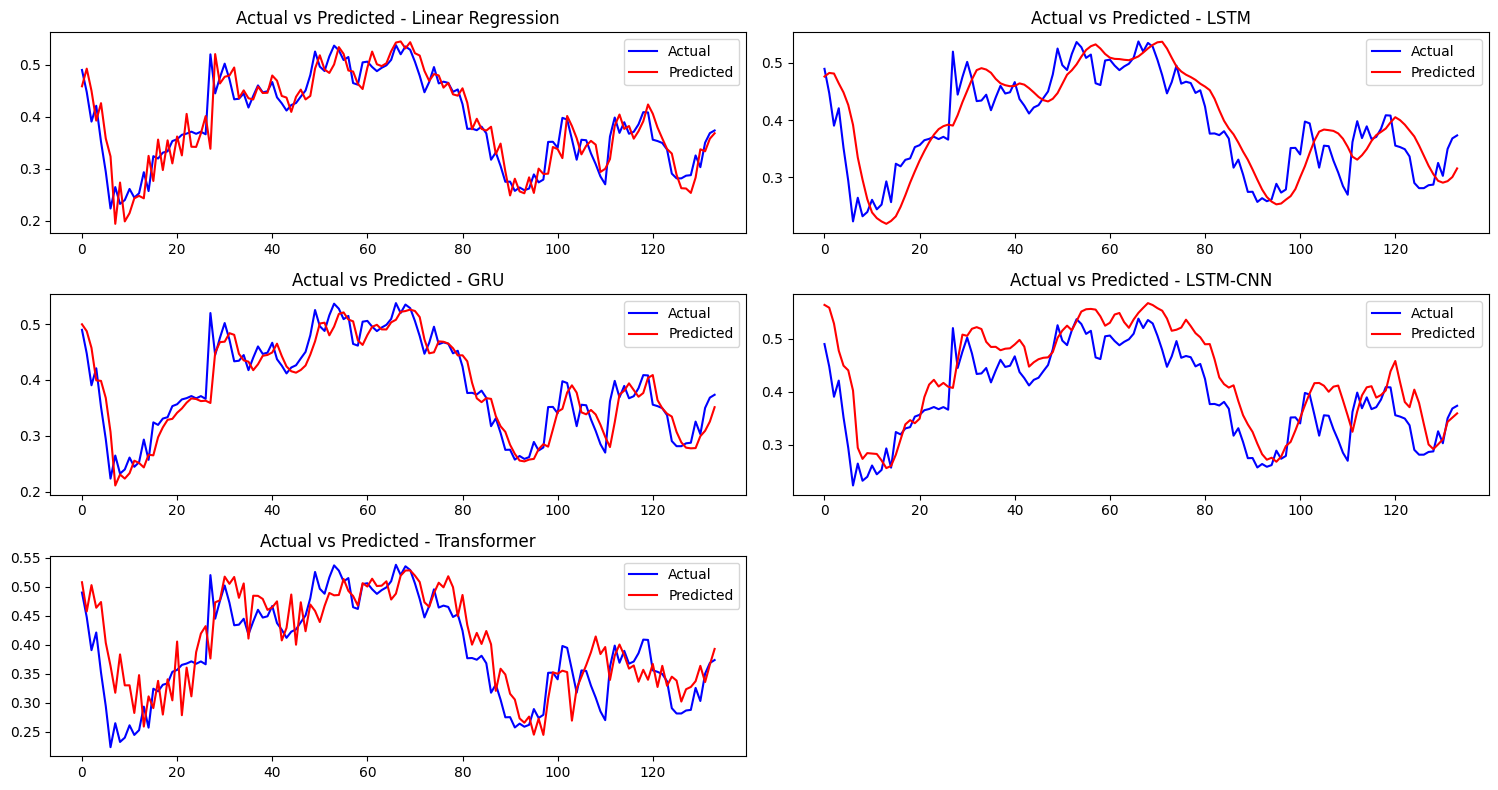

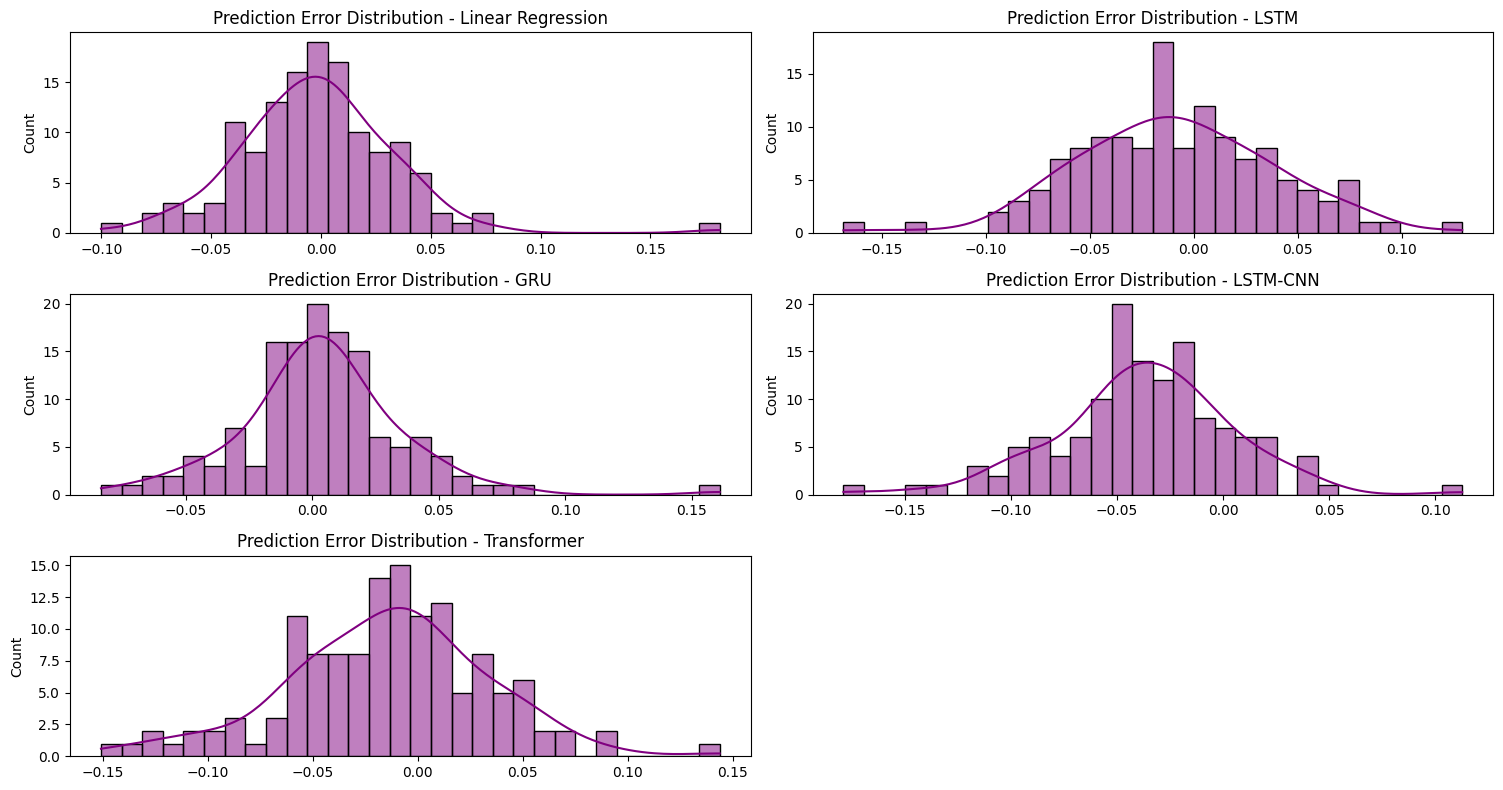

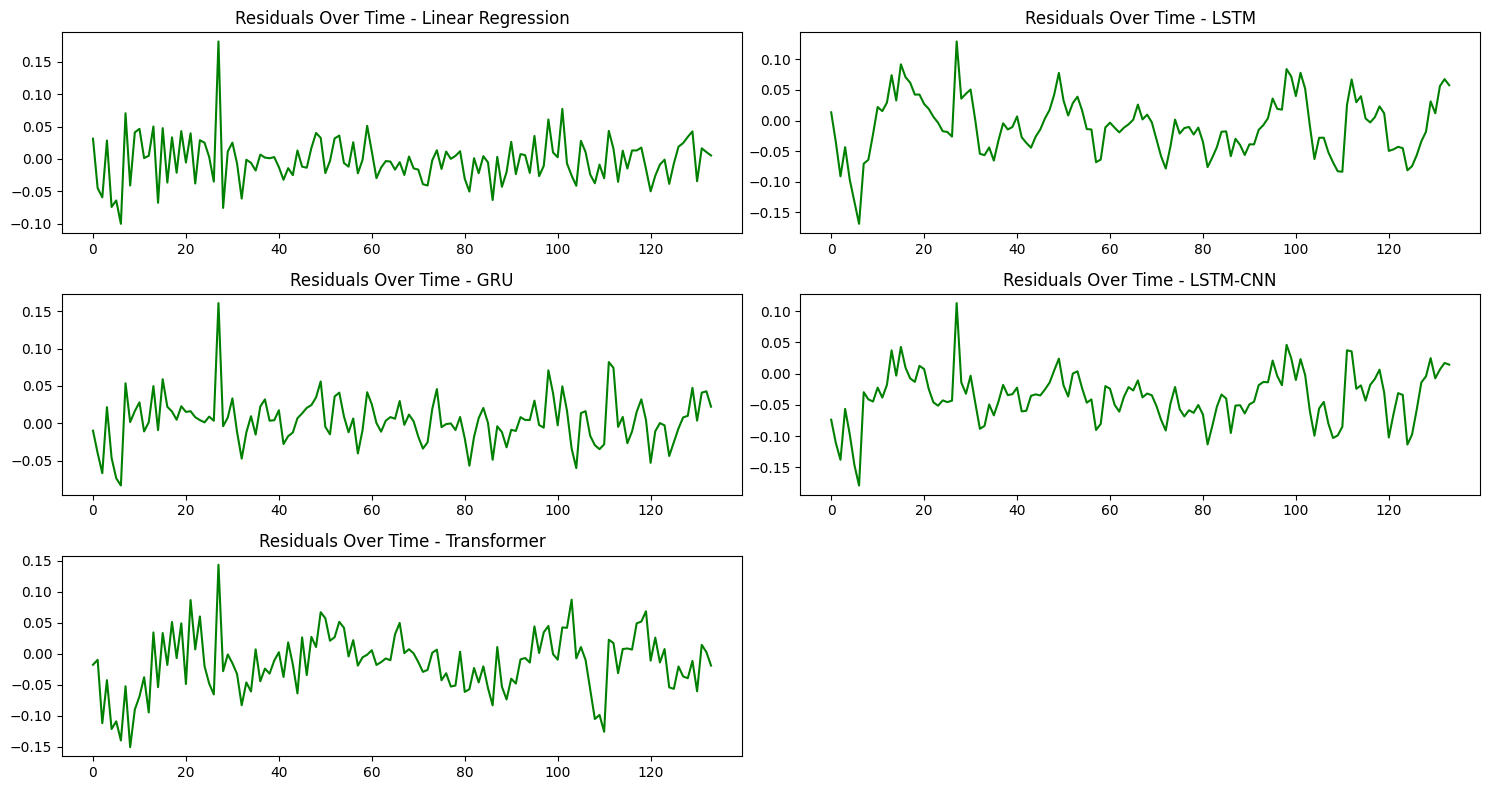

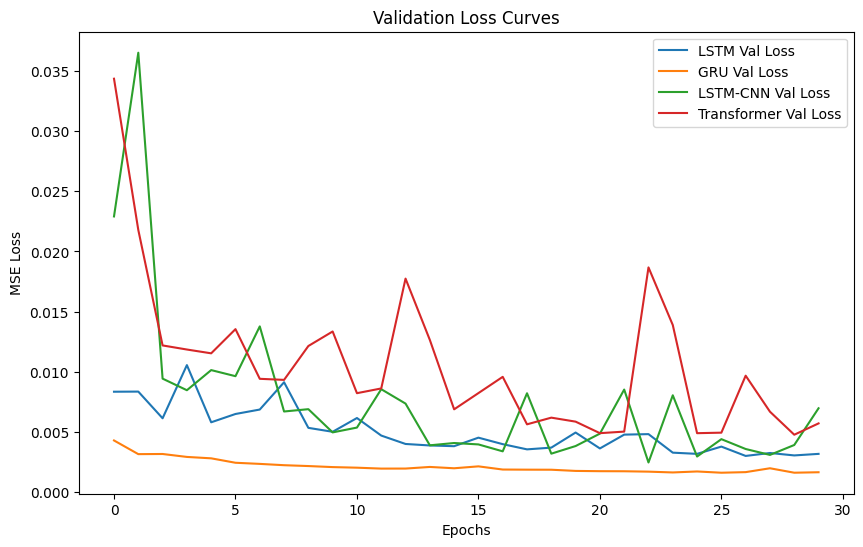

/tmp/ipython-input-1924761209.py:211: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=regression_models, y=mse_values, palette='Set2')


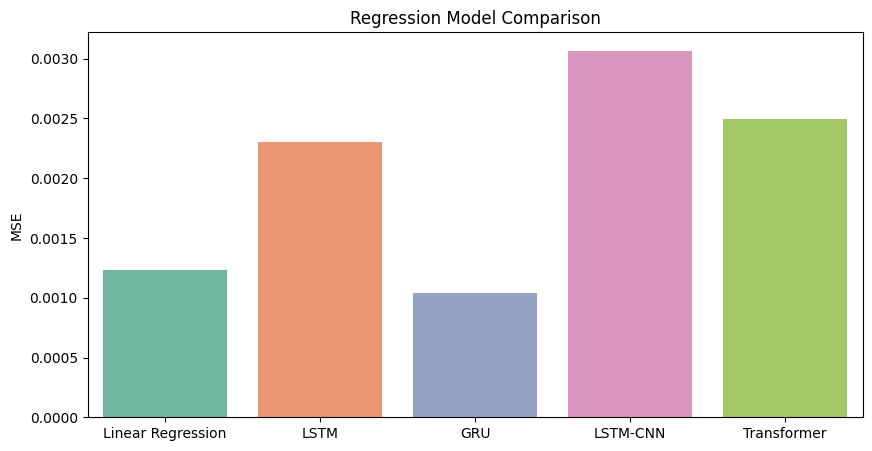

/tmp/ipython-input-1924761209.py:218: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=['Logistic Regression'], y=[results['Logistic Regression Accuracy']], palette='Set1')


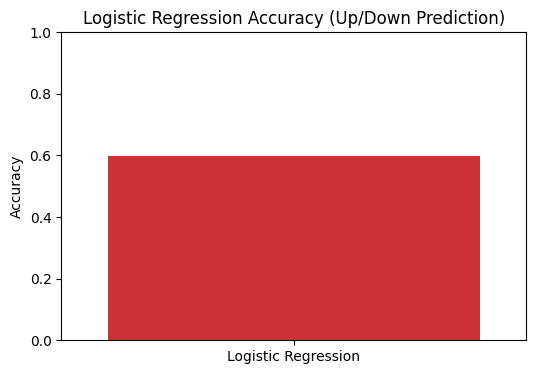

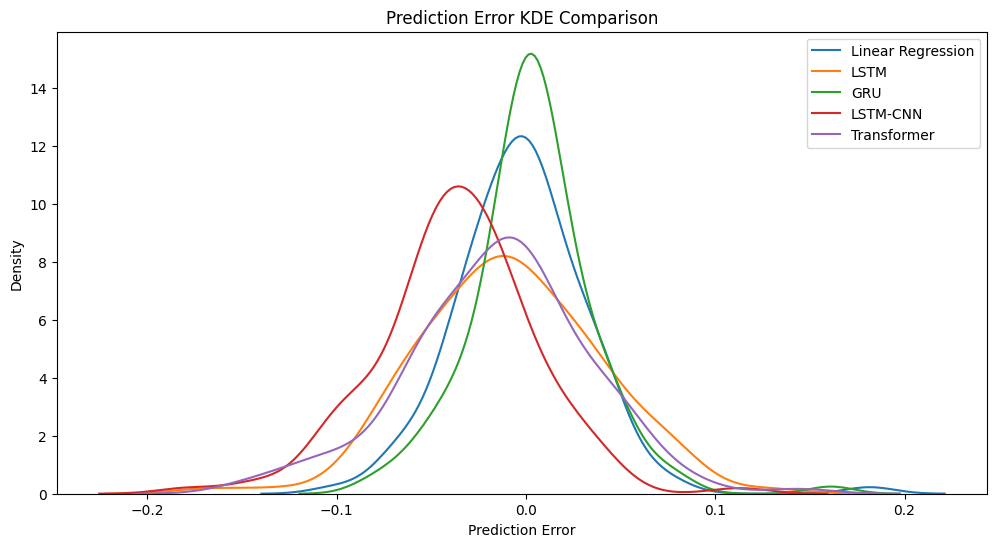

In [ ]:
# Install dependencies
!pip install tensorflow pandas scikit-learn matplotlib seaborn

# -------------------------------
# Step 1: Imports
# -------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error, accuracy_score
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Input, LSTM, GRU, Dense, Conv1D, Flatten, Dropout, Concatenate, LayerNormalization, MultiHeadAttention, Add
from google.colab import files

# -------------------------------
# Step 2: Upload CSV
# -------------------------------
uploaded = files.upload()
filename = list(uploaded.keys())[0]

df = pd.read_csv(filename, parse_dates=['date'])
df.sort_values('date', inplace=True)
df.reset_index(drop=True, inplace=True)
df = df[['open','high','low','close','volume']]
print(df.head())

# -------------------------------
# Step 3: Prepare sequences
# -------------------------------
def create_sequences(data, seq_len=20):
    X, y = [], []
    for i in range(seq_len, len(data)):
        X.append(data[i-seq_len:i])
        y.append(data[i, 3])  # Predict 'close'
    return np.array(X), np.array(y)

# Logistic regression target: up/down movement
df['UpDown'] = (df['close'].shift(-1) > df['close']).astype(int)
df = df.dropna()

# Scale features
features = ['open','high','low','close','volume']
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(df[features])

seq_len = 20
X_seq, y_seq = create_sequences(data_scaled, seq_len)
y_lr = df['close'].values[seq_len:]
y_logistic = df['UpDown'].values[seq_len:]

# Train-test split
split = int(0.8 * len(X_seq))
X_train, X_test = X_seq[:split], X_seq[split:]
y_train, y_test = y_seq[:split], y_seq[split:]
y_log_train, y_log_test = y_logistic[:split], y_logistic[split:]

# -------------------------------
# Step 4: Define models
# -------------------------------
def build_lstm(seq_len, n_features):
    model = Sequential()
    model.add(LSTM(50, return_sequences=True, input_shape=(seq_len, n_features)))
    model.add(LSTM(30))
    model.add(Dense(1))
    model.compile(optimizer='adam', loss='mse')
    return model

def build_gru(seq_len, n_features):
    model = Sequential()
    model.add(GRU(50, return_sequences=True, input_shape=(seq_len, n_features)))
    model.add(GRU(30))
    model.add(Dense(1))
    model.compile(optimizer='adam', loss='mse')
    return model

def build_lstm_cnn(seq_len, n_features):
    input_layer = Input(shape=(seq_len, n_features))
    lstm_out = LSTM(50, return_sequences=True)(input_layer)
    lstm_out = LSTM(30)(lstm_out)
    cnn_out = Conv1D(64, 3, activation='relu')(input_layer)
    cnn_out = Conv1D(32, 3, activation='relu')(cnn_out)
    cnn_out = Flatten()(cnn_out)
    combined = Concatenate()([lstm_out, cnn_out])
    combined = Dense(50, activation='relu')(combined)
    combined = Dropout(0.2)(combined)
    output = Dense(1)(combined)
    model = Model(inputs=input_layer, outputs=output)
    model.compile(optimizer='adam', loss='mse')
    return model

def build_transformer(seq_len, n_features, embed_dim=32, num_heads=2):
    input_layer = Input(shape=(seq_len, n_features))
    attn_output = MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)(input_layer, input_layer)
    attn_output = Add()([input_layer, attn_output])
    out = LayerNormalization()(attn_output)
    out = Flatten()(out)
    out = Dense(64, activation='relu')(out)
    out = Dense(1)(out)
    model = Model(inputs=input_layer, outputs=out)
    model.compile(optimizer='adam', loss='mse')
    return model

# -------------------------------
# Step 5: Train and evaluate
# -------------------------------
results = {}

# Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train.reshape(X_train.shape[0], -1), y_train)
y_pred_lr = lr_model.predict(X_test.reshape(X_test.shape[0], -1))
results['Linear Regression'] = mean_squared_error(y_test, y_pred_lr)

# Logistic Regression (up/down)
log_model = LogisticRegression(max_iter=500)
log_model.fit(X_train.reshape(X_train.shape[0], -1), y_log_train)
y_pred_log = log_model.predict(X_test.reshape(X_test.shape[0], -1))
results['Logistic Regression Accuracy'] = accuracy_score(y_log_test, y_pred_log)

# LSTM
lstm_model = build_lstm(seq_len, X_train.shape[2])
history_lstm = lstm_model.fit(X_train, y_train, epochs=30, batch_size=32, validation_split=0.2, verbose=0)
y_pred_lstm = lstm_model.predict(X_test)
results['LSTM MSE'] = mean_squared_error(y_test, y_pred_lstm)

# GRU
gru_model = build_gru(seq_len, X_train.shape[2])
history_gru = gru_model.fit(X_train, y_train, epochs=30, batch_size=32, validation_split=0.2, verbose=0)
y_pred_gru = gru_model.predict(X_test)
results['GRU MSE'] = mean_squared_error(y_test, y_pred_gru)

# LSTM-CNN
lstm_cnn_model = build_lstm_cnn(seq_len, X_train.shape[2])
history_lstm_cnn = lstm_cnn_model.fit(X_train, y_train, epochs=30, batch_size=32, validation_split=0.2, verbose=0)
y_pred_lstm_cnn = lstm_cnn_model.predict(X_test)
results['LSTM-CNN MSE'] = mean_squared_error(y_test, y_pred_lstm_cnn)

# Transformer
transformer_model = build_transformer(seq_len, X_train.shape[2])
history_transformer = transformer_model.fit(X_train, y_train, epochs=30, batch_size=32, validation_split=0.2, verbose=0)
y_pred_transformer = transformer_model.predict(X_test)
results['Transformer MSE'] = mean_squared_error(y_test, y_pred_transformer)

# -------------------------------
# Step 6: Plot comparison graphs
# -------------------------------
regression_models_preds = {
    'Linear Regression': y_pred_lr,
    'LSTM': y_pred_lstm,
    'GRU': y_pred_gru,
    'LSTM-CNN': y_pred_lstm_cnn,
    'Transformer': y_pred_transformer
}

# Actual vs Predicted
plt.figure(figsize=(15,8))
for i, (name, y_pred) in enumerate(regression_models_preds.items()):
    plt.subplot(3,2,i+1)
    plt.plot(y_test, label='Actual', color='blue')
    plt.plot(y_pred, label='Predicted', color='red')
    plt.title(f'Actual vs Predicted - {name}')
    plt.legend()
plt.tight_layout()
plt.show()

# Error distributions
plt.figure(figsize=(15,8))
for i, (name, y_pred) in enumerate(regression_models_preds.items()):
    plt.subplot(3,2,i+1)
    errors = y_test - y_pred.flatten()
    sns.histplot(errors, bins=30, kde=True, color='purple')
    plt.title(f'Prediction Error Distribution - {name}')
plt.tight_layout()
plt.show()

# Residuals over time
plt.figure(figsize=(15,8))
for i, (name, y_pred) in enumerate(regression_models_preds.items()):
    plt.subplot(3,2,i+1)
    residuals = y_test - y_pred.flatten()
    plt.plot(residuals, color='green')
    plt.title(f'Residuals Over Time - {name}')
plt.tight_layout()
plt.show()

# Validation loss curves
plt.figure(figsize=(10,6))
plt.plot(history_lstm.history['val_loss'], label='LSTM Val Loss')
plt.plot(history_gru.history['val_loss'], label='GRU Val Loss')
plt.plot(history_lstm_cnn.history['val_loss'], label='LSTM-CNN Val Loss')
plt.plot(history_transformer.history['val_loss'], label='Transformer Val Loss')
plt.title('Validation Loss Curves')
plt.xlabel('Epochs')
plt.ylabel('MSE Loss')
plt.legend()
plt.show()

# Regression MSE bar chart
regression_models = ['Linear Regression','LSTM','GRU','LSTM-CNN','Transformer']
mse_values = [
    results['Linear Regression'],
    results['LSTM MSE'],
    results['GRU MSE'],
    results['LSTM-CNN MSE'],
    results['Transformer MSE']
]
plt.figure(figsize=(10,5))
sns.barplot(x=regression_models, y=mse_values, palette='Set2')
plt.ylabel('MSE')
plt.title('Regression Model Comparison')
plt.show()

# Logistic Regression Accuracy
plt.figure(figsize=(6,4))
sns.barplot(x=['Logistic Regression'], y=[results['Logistic Regression Accuracy']], palette='Set1')
plt.ylabel('Accuracy')
plt.ylim(0,1)
plt.title('Logistic Regression Accuracy (Up/Down Prediction)')
plt.show()

# Error KDE Comparison
plt.figure(figsize=(12,6))
for name, y_pred in regression_models_preds.items():
    errors = y_test - y_pred.flatten()
    sns.kdeplot(errors, label=name)
plt.title('Prediction Error KDE Comparison')
plt.xlabel('Prediction Error')
plt.ylabel('Density')
plt.legend()
plt.show()
